# Evaluación comparativa de estrategias sistemáticas de trading mediante análisis técnico y modelos de series temporales

### Asignatura: Business Analytics. Enfoque funcional y sectorial. Visión práctica
### Alumno: Juan A. Sánchez Salvador
#### Trabajo final de la asignatura


## Planteamiento del trabajo

El objetivo es comparar distintas estrategias sistemáticas de inversión aplicadas a varios activos financieros con comportamientos de mercado diferentes. 
Se comparan tres enfoques principales:

1. **Buy and Hold**, utilizado como benchmark base. Consiste en comprar el activo al inicio del periodo y mantenerlo hasta el final.
2. **Estrategia técnica Long/Cash basada en medias móviles**, que entra en el mercado cuando la media móvil corta supera a la media móvil larga y permanece en liquidez cuando la señal no es favorable.
3. **Estrategia predictiva Long/Cash basada en ARIMA/AutoARIMA**, que utiliza modelos de series temporales para generar señales de entrada o salida en función de la predicción del retorno futuro.

La comparación se realiza sobre activos de distinta naturaleza, incluyendo índices bursátiles, acciones individuales, criptomonedas, materias primas y divisas. Esta variedad permite analizar si las estrategias funcionan de forma consistente o si su rendimiento depende del tipo de activo y del régimen de mercado.

## Enfoque metodológico

El análisis sigue una estructura progresiva. Primero se descargan y preparan los datos históricos de precios. Después se calcula el rendimiento del benchmark Buy and Hold. A continuación se implementan dos estrategias activas: una basada en reglas técnicas de medias móviles y otra basada en modelos de series temporales.

Para evitar una evaluación demasiado optimista, el periodo histórico se divide en dos partes:

* **Train**, utilizado para seleccionar parámetros o ajustar modelos.
* **Test**, utilizado para evaluar el comportamiento fuera de muestra.

Esta separación es importante porque permite comprobar si una estrategia mantiene resultados razonables en datos que no han sido utilizados durante la fase de ajuste.

Las estrategias activas se implementan bajo un enfoque **Long/Cash**. Esto significa que la estrategia puede estar invertida en el activo o permanecer fuera del mercado, pero no toma posiciones cortas. Por tanto, cuando no existe señal favorable, la estrategia pasa a liquidez.

## Métricas de evaluación

Las estrategias se comparan utilizando métricas habituales en análisis financiero cuantitativo:

* **Rentabilidad total**, para medir cuánto crece el capital durante el periodo analizado.
* **Rentabilidad anualizada**, para facilitar la comparación entre estrategias.
* **Volatilidad anualizada**, como medida de riesgo.
* **Ratio de Sharpe**, para evaluar la rentabilidad obtenida por unidad de riesgo.
* **Máximo drawdown**, para medir la mayor caída desde un máximo previo de capital.
* **Número de operaciones y costes de transacción**, para valorar el impacto práctico de entrar y salir del mercado.

Estas métricas permiten distinguir entre estrategias que maximizan rentabilidad y estrategias que, aunque no siempre ganen más, pueden reducir el riesgo o las caídas máximas.

## Estructura del notebook

El notebook se organiza de la siguiente forma:

1. Planteamiento del proyecto y metodología general.
2. Descarga, limpieza y preparación de datos.
3. Construcción del benchmark Buy and Hold.
4. Implementación y optimización de la estrategia técnica basada en medias móviles.
5. Implementación de la estrategia predictiva basada en ARIMA/AutoARIMA.
6. Comparación global entre estrategias.
7. Análisis por régimen de mercado.
8. Discusión crítica sobre robustez, sobreajuste y limitaciones.
9. Anexo práctico en TradingView para visualizar señales de entrada, salida y control de riesgo.
10. Conclusiones finales.

La formulación matemática detallada de cada estrategia se presenta en su sección correspondiente, evitando duplicar explicaciones en la introducción.

# 1. Configuración del entorno y las variables


In [1]:
# ============================================================
# 1. CONFIGURACIÓN INICIAL DEL PROYECTO
# ============================================================

#import sys
#!{sys.executable} -m pip install pmdarima
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

try:
    from pmdarima import auto_arima
except ImportError as exc:
    raise ImportError(
        "pmdarima no está instalado. Para ejecutar la estrategia AutoARIMA, instala el paquete con:\n"
        "conda install -c conda-forge pmdarima -y\n"
        "o bien:\n"
        "python -m pip install pmdarima"
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (12, 6)


# ============================================================
# 2. DEFINICIÓN DE RUTAS DEL PROYECTO
# ============================================================

PROJECT_ROOT = Path(r"D:\Master en Business Analytics\enfoque funcional y sectorial\Trabajo Final")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

for folder in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Ruta raíz del proyecto: {PROJECT_ROOT}")
print(f"Carpeta de resultados: {OUTPUTS_DIR}")


# ============================================================
# 3. CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

START_DATE = "2018-01-01"
END_DATE = None
INTERVAL = "1d"

ASSETS = {
    "BTC-USD": "Bitcoin",
    "SPY": "S&P 500 ETF",
    "QQQ": "Nasdaq 100 ETF",
    "AAPL": "Apple",
    "PG": "Procter & Gamble",
    "GLD": "Gold ETF",
    "EURUSD=X": "EUR/USD"
}

TICKERS = list(ASSETS.keys())

asset_metadata = pd.DataFrame({
    "ticker": ASSETS.keys(),
    "asset_name": ASSETS.values(),
    "asset_class": [
        "Criptomoneda",
        "Índice / ETF",
        "Índice / ETF tecnológico",
        "Acción tecnológica",
        "Acción consumo defensivo",
        "Materia prima / ETF",
        "Divisa"
    ],
    "rationale": [
        "Activo digital con alta volatilidad y comportamiento tendencial en determinados periodos.",
        "Referencia amplia del mercado bursátil estadounidense.",
        "Referencia del sector tecnológico y empresas de crecimiento.",
        "Acción individual de gran capitalización vinculada al sector tecnológico.",
        "Acción defensiva de consumo básico, menos cíclica que tecnología.",
        "Activo refugio utilizado para diversificación frente a renta variable.",
        "Mercado de divisas, útil para conectar con la práctica inicial de análisis técnico."
    ]
})

display(asset_metadata)


# ============================================================
# 4. DESCARGA DE DATOS CON YFINANCE
# ============================================================

raw_data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    auto_adjust=True,
    group_by="ticker",
    progress=False,
    threads=True
)

if raw_data.empty:
    raise ValueError("No se han descargado datos. Revisa conexión, tickers o fechas.")

print("Datos descargados correctamente.")
print(f"Dimensiones del dataset bruto: {raw_data.shape}")


# ============================================================
# 5. FUNCIÓN AUXILIAR PARA EXTRAER CAMPOS OHLCV
# ============================================================

def extract_yfinance_field(data, field, tickers):
    """
    Extrae un campo concreto de un DataFrame descargado con yfinance.
    Permite trabajar con estructuras MultiIndex generadas por varios tickers.
    """
    if isinstance(data.columns, pd.MultiIndex):
        level_0 = data.columns.get_level_values(0)
        level_1 = data.columns.get_level_values(1)

        if field in level_1:
            extracted = data.xs(field, level=1, axis=1).copy()
        elif field in level_0:
            extracted = data[field].copy()
        else:
            raise ValueError(f"No se encuentra el campo {field} en los datos descargados.")
    else:
        if field not in data.columns:
            raise ValueError(f"No se encuentra el campo {field} en los datos descargados.")
        extracted = data[[field]].copy()
        extracted.columns = tickers

    available_tickers = [ticker for ticker in tickers if ticker in extracted.columns]
    return extracted[available_tickers]


close_prices = extract_yfinance_field(raw_data, "Close", TICKERS)
open_prices = extract_yfinance_field(raw_data, "Open", TICKERS)
high_prices = extract_yfinance_field(raw_data, "High", TICKERS)
low_prices = extract_yfinance_field(raw_data, "Low", TICKERS)
volume = extract_yfinance_field(raw_data, "Volume", TICKERS)


# ============================================================
# 6. CÁLCULO DE RETORNOS
# ============================================================

def calculate_log_returns_by_asset(price_df):
    """
    Calcula retornos logarítmicos por activo.
    Cada serie se limpia de forma individual para no perder observaciones válidas
    por diferencias de calendario entre activos.
    """
    returns_dict = {}

    for ticker in price_df.columns:
        clean_prices = price_df[ticker].dropna()
        returns_dict[ticker] = np.log(clean_prices / clean_prices.shift(1))

    return pd.DataFrame(returns_dict)


def calculate_simple_returns_by_asset(price_df):
    """
    Calcula retornos simples por activo.
    """
    returns_dict = {}

    for ticker in price_df.columns:
        clean_prices = price_df[ticker].dropna()
        returns_dict[ticker] = clean_prices.pct_change()

    return pd.DataFrame(returns_dict)


log_returns = calculate_log_returns_by_asset(close_prices)
simple_returns = calculate_simple_returns_by_asset(close_prices)


# ============================================================
# 7. CONTROL DE CALIDAD DE LOS DATOS
# ============================================================

data_quality = pd.DataFrame({
    "ticker": close_prices.columns,
    "asset_name": [ASSETS[ticker] for ticker in close_prices.columns],
    "first_date": close_prices.apply(lambda x: x.first_valid_index()),
    "last_date": close_prices.apply(lambda x: x.last_valid_index()),
    "n_observations": close_prices.count(),
    "missing_values": close_prices.isna().sum(),
    "missing_pct": (close_prices.isna().mean() * 100).round(2)
}).reset_index(drop=True)

display(data_quality)


# ============================================================
# 8. GUARDADO DE DATOS PARA REPLICABILIDAD
# ============================================================

close_prices.to_csv(RAW_DATA_DIR / "close_prices.csv")
open_prices.to_csv(RAW_DATA_DIR / "open_prices.csv")
high_prices.to_csv(RAW_DATA_DIR / "high_prices.csv")
low_prices.to_csv(RAW_DATA_DIR / "low_prices.csv")
volume.to_csv(RAW_DATA_DIR / "volume.csv")

log_returns.to_csv(PROCESSED_DATA_DIR / "log_returns.csv")
simple_returns.to_csv(PROCESSED_DATA_DIR / "simple_returns.csv")
asset_metadata.to_csv(PROCESSED_DATA_DIR / "asset_metadata.csv", index=False)
data_quality.to_csv(PROCESSED_DATA_DIR / "data_quality_report.csv", index=False)

print("Archivos guardados correctamente.")

Ruta raíz del proyecto: D:\Master en Business Analytics\enfoque funcional y sectorial\Trabajo Final
Carpeta de resultados: D:\Master en Business Analytics\enfoque funcional y sectorial\Trabajo Final\outputs


,ticker,asset_name,asset_class,rationale
0,BTC-USD,Bitcoin,Criptomoneda,Activo digital con alta volatilidad y comporta...
1,SPY,S&P 500 ETF,Índice / ETF,Referencia amplia del mercado bursátil estadou...
2,QQQ,Nasdaq 100 ETF,Índice / ETF tecnológico,Referencia del sector tecnológico y empresas d...
3,AAPL,Apple,Acción tecnológica,Acción individual de gran capitalización vincu...
4,PG,Procter & Gamble,Acción consumo defensivo,"Acción defensiva de consumo básico, menos cícl..."
5,GLD,Gold ETF,Materia prima / ETF,Activo refugio utilizado para diversificación ...
6,EURUSD=X,EUR/USD,Divisa,"Mercado de divisas, útil para conectar con la ..."


Datos descargados correctamente.
Dimensiones del dataset bruto: (3092, 35)


,ticker,asset_name,first_date,last_date,n_observations,missing_values,missing_pct
0,BTC-USD,Bitcoin,2018-01-01,2026-06-18,3091,1,0.03
1,SPY,S&P 500 ETF,2018-01-02,2026-06-18,2127,965,31.21
2,QQQ,Nasdaq 100 ETF,2018-01-02,2026-06-18,2127,965,31.21
3,AAPL,Apple,2018-01-02,2026-06-18,2127,965,31.21
4,PG,Procter & Gamble,2018-01-02,2026-06-18,2127,965,31.21
5,GLD,Gold ETF,2018-01-02,2026-06-18,2127,965,31.21
6,EURUSD=X,EUR/USD,2018-01-01,2026-06-19,2204,888,28.72


Archivos guardados correctamente.


# 2. Análisis exploratorio de los activos seleccionados

Antes de implementar las estrategias de trading, se realiza un análisis exploratorio de los activos seleccionados. El objetivo es comprobar si los activos presentan comportamientos suficientemente diferentes como para justificar su inclusión en el estudio.

En esta sección se analizan:

- la evolución normalizada de los precios;
- la rentabilidad acumulada de cada activo;
- la media y volatilidad de los retornos;
- la correlación entre activos;
- la comparación preliminar entre activos de mayor riesgo y activos más defensivos.

Este análisis es importante porque una estrategia de trading no debería evaluarse únicamente sobre un activo concreto. Por ejemplo, una regla que funciona bien en Bitcoin puede no funcionar de la misma forma en un ETF amplio como el S&P 500, en una acción defensiva como Procter & Gamble o en un activo refugio como el oro.

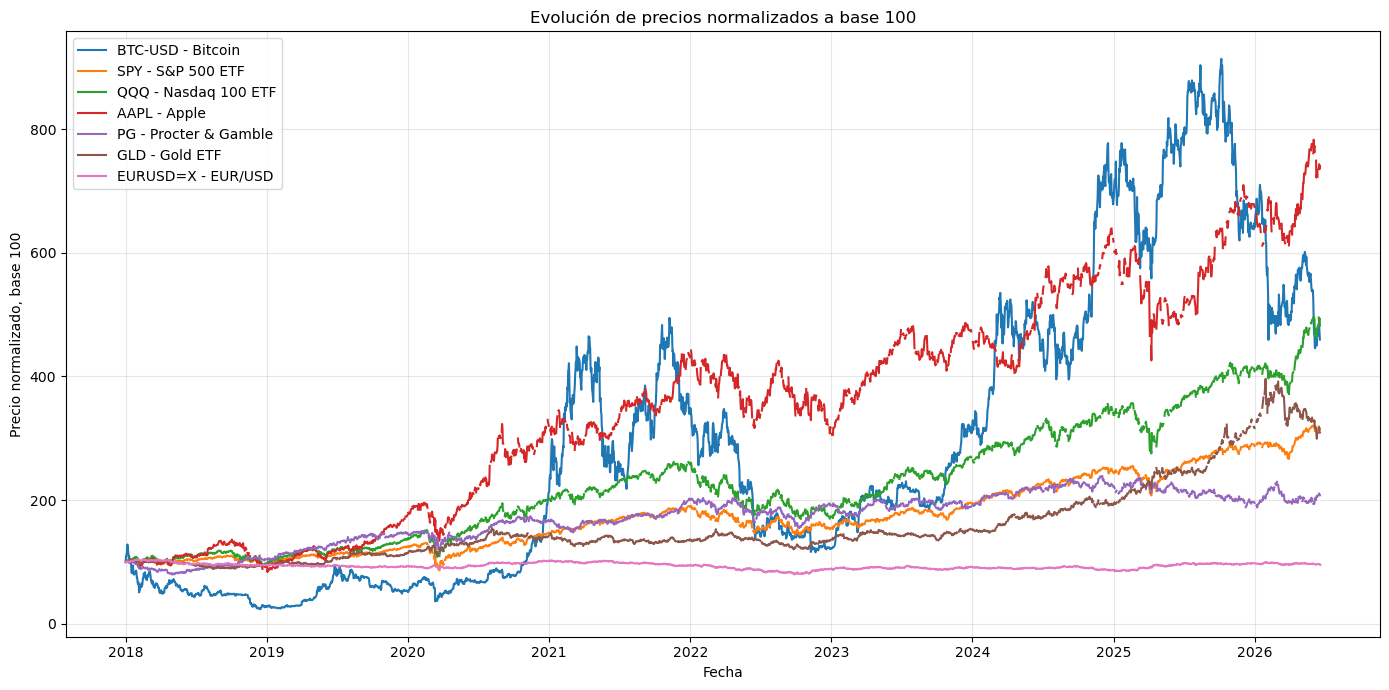

In [2]:
# ============================================================
# 2.1 PRECIOS NORMALIZADOS A BASE 100
# ============================================================

first_valid_prices = close_prices.apply(lambda x: x.dropna().iloc[0])
normalized_prices = close_prices.div(first_valid_prices, axis=1) * 100


plt.figure(figsize=(14, 7))

for ticker in normalized_prices.columns:
    plt.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        label=f"{ticker} - {ASSETS[ticker]}"
    )

plt.title("Evolución de precios normalizados a base 100")
plt.xlabel("Fecha")
plt.ylabel("Precio normalizado, base 100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "normalized_prices.png", dpi=300)
plt.show()

In [3]:
# ============================================================
# 2.2 ESTADÍSTICAS DESCRIPTIVAS DE RETORNOS
# ============================================================

# Se calculan métricas básicas sobre retornos logarítmicos diarios.
# La anualización se realiza con 252 sesiones para mantener una comparación homogénea.
# En BTC es una aproximación, ya que cotiza todos los días.

TRADING_DAYS = 252

returns_summary = pd.DataFrame(index=log_returns.columns)

returns_summary["asset_name"] = [ASSETS[ticker] for ticker in returns_summary.index]
returns_summary["n_observations"] = log_returns.count()
returns_summary["mean_daily_return"] = log_returns.mean()
returns_summary["daily_volatility"] = log_returns.std()
returns_summary["annualized_return"] = log_returns.mean() * TRADING_DAYS
returns_summary["annualized_volatility"] = log_returns.std() * np.sqrt(TRADING_DAYS)
returns_summary["buy_hold_total_return"] = np.exp(log_returns.sum()) - 1

# Métricas adicionales calculadas para trazabilidad, pero no mostradas en la tabla principal
returns_summary["min_daily_return"] = log_returns.min()
returns_summary["max_daily_return"] = log_returns.max()
returns_summary["skewness"] = log_returns.skew()
returns_summary["kurtosis"] = log_returns.kurtosis()

# Guardar tabla completa para reproducibilidad
returns_summary.round(4).to_csv(TABLES_DIR / "returns_summary_full.csv")

# Tabla compacta para mostrar en el notebook
returns_summary_display = returns_summary[
    [
        "asset_name",
        "n_observations",
        "annualized_return",
        "annualized_volatility",
        "buy_hold_total_return"
    ]
].copy()

numeric_cols = returns_summary_display.select_dtypes(include=[np.number]).columns
returns_summary_display[numeric_cols] = returns_summary_display[numeric_cols].round(4)

display(returns_summary_display)

# Guardar tabla compacta mostrada en el notebook
returns_summary_display.to_csv(TABLES_DIR / "returns_summary_display.csv")

,asset_name,n_observations,annualized_return,annualized_volatility,buy_hold_total_return
BTC-USD,Bitcoin,3090,0.1244,0.5378,3.5965
SPY,S&P 500 ETF,2126,0.1363,0.1925,2.1566
QQQ,Nasdaq 100 ETF,2126,0.1891,0.2391,3.9302
AAPL,Apple,2126,0.2373,0.3044,6.4008
PG,Procter & Gamble,2126,0.0868,0.2006,1.0805
GLD,Gold ETF,2126,0.1338,0.1683,2.0932
EURUSD=X,EUR/USD,2203,-0.0053,0.0715,-0.0451


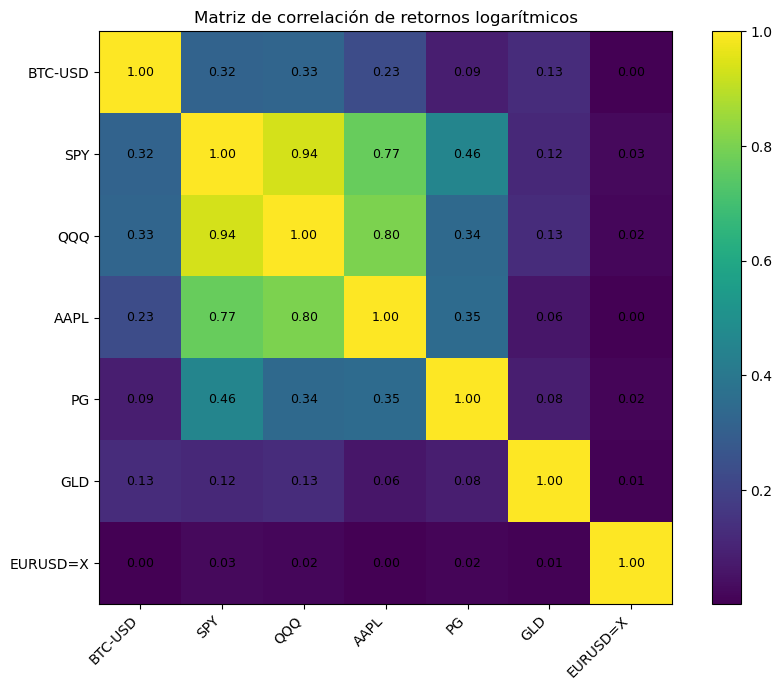

In [4]:
# ============================================================
# 2.3 MATRIZ DE CORRELACIÓN ENTRE ACTIVOS
# ============================================================

# Se calcula la correlación usando únicamente fechas comunes a todos los activos.
# Esto evita distorsiones por diferencias de calendario, especialmente porque BTC cotiza 24/7.

common_returns = log_returns.dropna(how="any")
correlation_matrix = common_returns.corr()

# Guardar tabla completa para reproducibilidad
correlation_matrix.round(3).to_csv(TABLES_DIR / "correlation_matrix.csv")


# Gráfico de matriz de correlación
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(correlation_matrix)

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title("Matriz de correlación de retornos logarítmicos")
fig.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300)
plt.show()

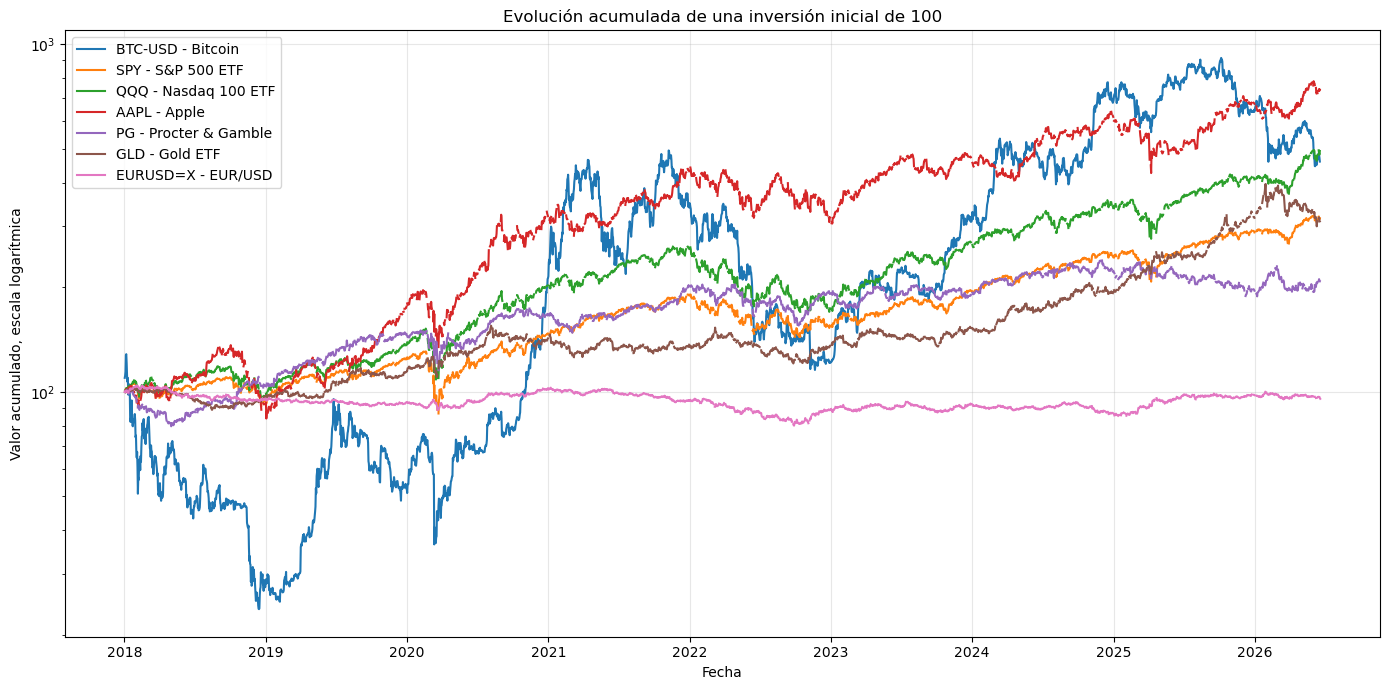

In [5]:
# ============================================================
# 2.4 EVOLUCIÓN ACUMULADA DE UNA INVERSIÓN INICIAL
# ============================================================

INITIAL_CAPITAL = 100.0

cumulative_returns = INITIAL_CAPITAL * np.exp(log_returns.cumsum())

plt.figure(figsize=(14, 7))

for ticker in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[ticker],
        label=f"{ticker} - {ASSETS[ticker]}"
    )

plt.yscale("log")
plt.title("Evolución acumulada de una inversión inicial de 100")
plt.xlabel("Fecha")
plt.ylabel("Valor acumulado, escala logarítmica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "cumulative_returns_log_scale.png", dpi=300)
plt.show()

El análisis exploratorio muestra diferencias relevantes entre los activos seleccionados. Bitcoin y Apple presentan las mayores rentabilidades acumuladas durante el periodo analizado, aunque con perfiles de riesgo distintos. Bitcoin destaca por una volatilidad anualizada muy superior al resto de activos, mientras que Apple combina una rentabilidad acumulada elevada con una volatilidad inferior a la de BTC.

Los ETFs SPY y QQQ muestran una correlación muy elevada, lo que resulta coherente al representar ambos una parte importante del mercado bursátil estadounidense. No obstante, QQQ presenta una mayor exposición al segmento tecnológico y de crecimiento, mientras que SPY representa una cartera más amplia y diversificada.

La inclusión de Procter & Gamble permite incorporar una acción de consumo defensivo, con una correlación claramente inferior respecto al Nasdaq 100. Por su parte, GLD presenta una correlación baja con la renta variable, lo que refuerza su papel como activo diversificador. Finalmente, EUR/USD muestra una correlación prácticamente nula con el resto de activos, aportando un mercado de naturaleza diferente al análisis.

Estos resultados justifican la necesidad de evaluar las estrategias de trading en distintos activos. Una estrategia puede funcionar adecuadamente en activos con alta tendencia o volatilidad, como Bitcoin o Apple, pero no necesariamente generalizar a activos más defensivos, descorrelacionados o con menor direccionalidad acumulada.

# 3. Benchmark Buy and Hold

La primera estrategia evaluada es **Buy and Hold**, que se utiliza como benchmark de referencia para comparar las estrategias activas desarrolladas posteriormente.

La lógica de esta estrategia consiste en comprar el activo al inicio del periodo de análisis y mantener la posición hasta el final, sin generar señales de entrada y salida durante el periodo intermedio. Por tanto, el retorno de la estrategia coincide directamente con el retorno del activo:

$$
r^{BH}_t = r_t
$$

donde (r_t) representa el retorno logarítmico del activo en el instante (t).

La evolución acumulada de una inversión inicial se calcula como:

$$
V_t = V_0 \cdot e^{\sum_{i=1}^{t} r_i}
$$

donde:

* (V_0) es el capital inicial;
* (r_i) son los retornos logarítmicos del activo;
* (V_t) es el valor acumulado de la inversión en el instante (t).

Este benchmark permite responder a una pregunta básica: si una estrategia activa no mejora a Buy and Hold en términos de rentabilidad ajustada por riesgo o control de pérdidas, entonces su mayor complejidad operativa puede no estar justificada.


In [6]:
# ============================================================
# 3. BENCHMARK BUY AND HOLD
# ============================================================

INITIAL_CAPITAL = 100.0

# La estrategia Buy and Hold toma directamente los retornos del activo.
buy_hold_returns = log_returns.copy()

# Curva de capital acumulada:
# V_t = V_0 * exp(sum(r_t))
buy_hold_equity = INITIAL_CAPITAL * np.exp(buy_hold_returns.cumsum())

In [7]:
# ============================================================
# 3.1 FUNCIÓN DE MÉTRICAS FINANCIERAS
# ============================================================

def calculate_performance_metrics(returns, equity_curve, initial_capital=100.0):
    """
    Calcula métricas principales de rentabilidad y riesgo para una estrategia.
    """
    
    returns = returns.dropna()
    equity_curve = equity_curve.dropna()
    
    if len(returns) == 0 or len(equity_curve) == 0:
        return {
            "total_return": np.nan,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
            "final_equity": np.nan,
            "n_observations": 0
        }
    
    start_date = equity_curve.index[0]
    end_date = equity_curve.index[-1]
    years = (end_date - start_date).days / 365.25
    
    if years <= 0:
        years = np.nan
    
    final_equity = equity_curve.iloc[-1]
    total_return = (final_equity / initial_capital) - 1
    
    annualized_return = (
        (final_equity / initial_capital) ** (1 / years) - 1
        if years and years > 0
        else np.nan
    )
    
    observations_per_year = len(returns) / years if years and years > 0 else np.nan
    annualized_volatility = returns.std() * np.sqrt(observations_per_year)
    
    sharpe_ratio = (
        annualized_return / annualized_volatility
        if annualized_volatility and annualized_volatility != 0
        else np.nan
    )
    
    running_max = equity_curve.cummax()
    drawdown = (equity_curve / running_max) - 1
    max_drawdown = drawdown.min()
    
    return {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": max_drawdown,
        "final_equity": final_equity,
        "n_observations": len(returns)
    }


# ============================================================
# 3.2 MÉTRICAS BUY AND HOLD POR ACTIVO
# ============================================================

buy_hold_metrics = []

for ticker in buy_hold_returns.columns:
    metrics = calculate_performance_metrics(
        returns=buy_hold_returns[ticker],
        equity_curve=buy_hold_equity[ticker],
        initial_capital=INITIAL_CAPITAL
    )
    
    metrics["ticker"] = ticker
    metrics["asset_name"] = ASSETS[ticker]
    metrics["strategy"] = "Buy and Hold"
    
    buy_hold_metrics.append(metrics)

buy_hold_metrics_df = pd.DataFrame(buy_hold_metrics)

buy_hold_metrics_df = buy_hold_metrics_df[
    [
        "strategy",
        "ticker",
        "asset_name",
        "final_equity",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "n_observations"
    ]
]

# Guardar tabla completa
buy_hold_metrics_df.round(4).to_csv(
    TABLES_DIR / "buy_hold_metrics_full.csv",
    index=False
)

# Tabla compacta para mostrar en el notebook
buy_hold_metrics_display = buy_hold_metrics_df[
    [
        "ticker",
        "asset_name",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "n_observations"
    ]
].copy()

cols_to_round = [
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown"
]

buy_hold_metrics_display[cols_to_round] = buy_hold_metrics_display[cols_to_round].round(4)

display(buy_hold_metrics_display)

buy_hold_metrics_display.to_csv(
    TABLES_DIR / "buy_hold_metrics_display.csv",
    index=False
)

,ticker,asset_name,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_observations
0,BTC-USD,Bitcoin,3.5965,0.1976,0.6476,0.3052,-0.8153,3090
1,SPY,S&P 500 ETF,2.1566,0.1456,0.1923,0.7575,-0.3372,2126
2,QQQ,Nasdaq 100 ETF,3.9302,0.2077,0.2389,0.8694,-0.3512,2126
3,AAPL,Apple,6.4008,0.2671,0.3041,0.8785,-0.3852,2126
4,PG,Procter & Gamble,1.0805,0.0905,0.2004,0.4517,-0.2377,2126
5,GLD,Gold ETF,2.0932,0.1429,0.1681,0.8500,-0.2446,2126
6,EURUSD=X,EUR/USD,-0.0451,-0.0054,0.0727,-0.0747,-0.2329,2203


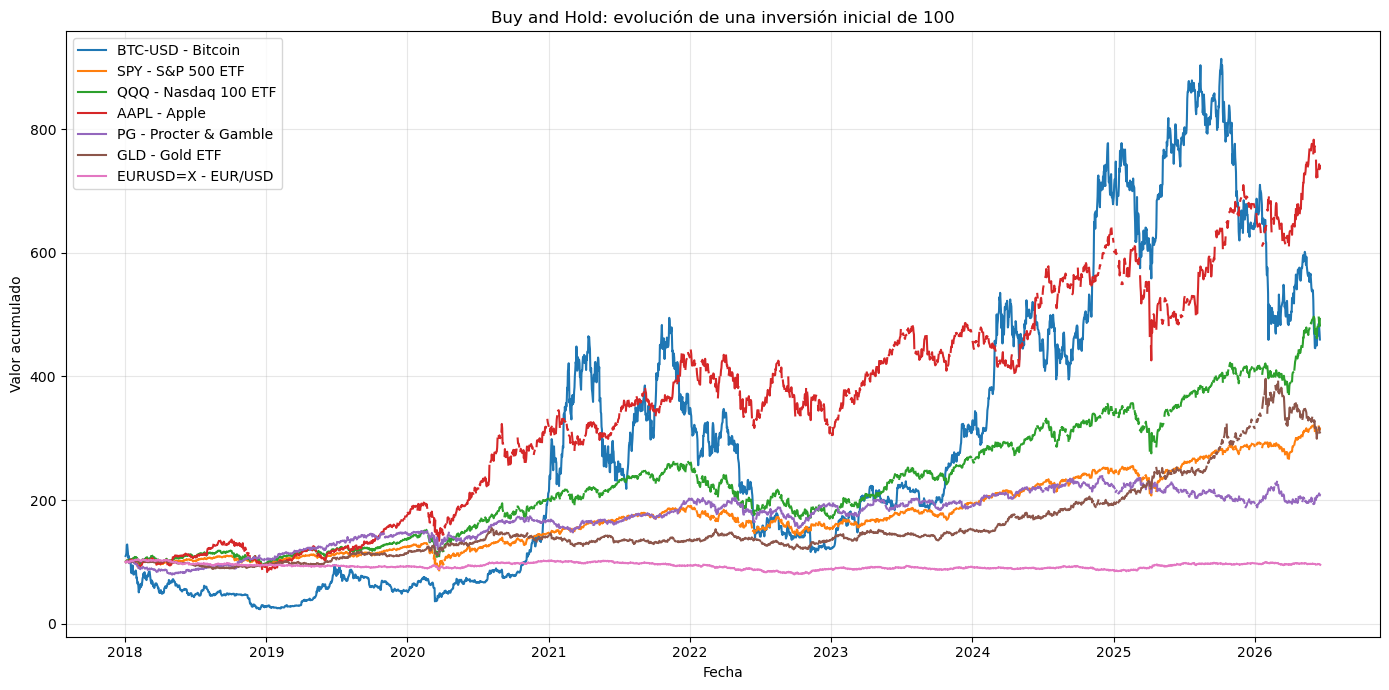

In [8]:
# ============================================================
# 3.3 CURVAS DE CAPITAL BUY AND HOLD
# ============================================================

plt.figure(figsize=(14, 7))

for ticker in buy_hold_equity.columns:
    plt.plot(
        buy_hold_equity.index,
        buy_hold_equity[ticker],
        label=f"{ticker} - {ASSETS[ticker]}"
    )

plt.title("Buy and Hold: evolución de una inversión inicial de 100")
plt.xlabel("Fecha")
plt.ylabel("Valor acumulado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "buy_hold_equity_curves.png", dpi=300)
plt.show()

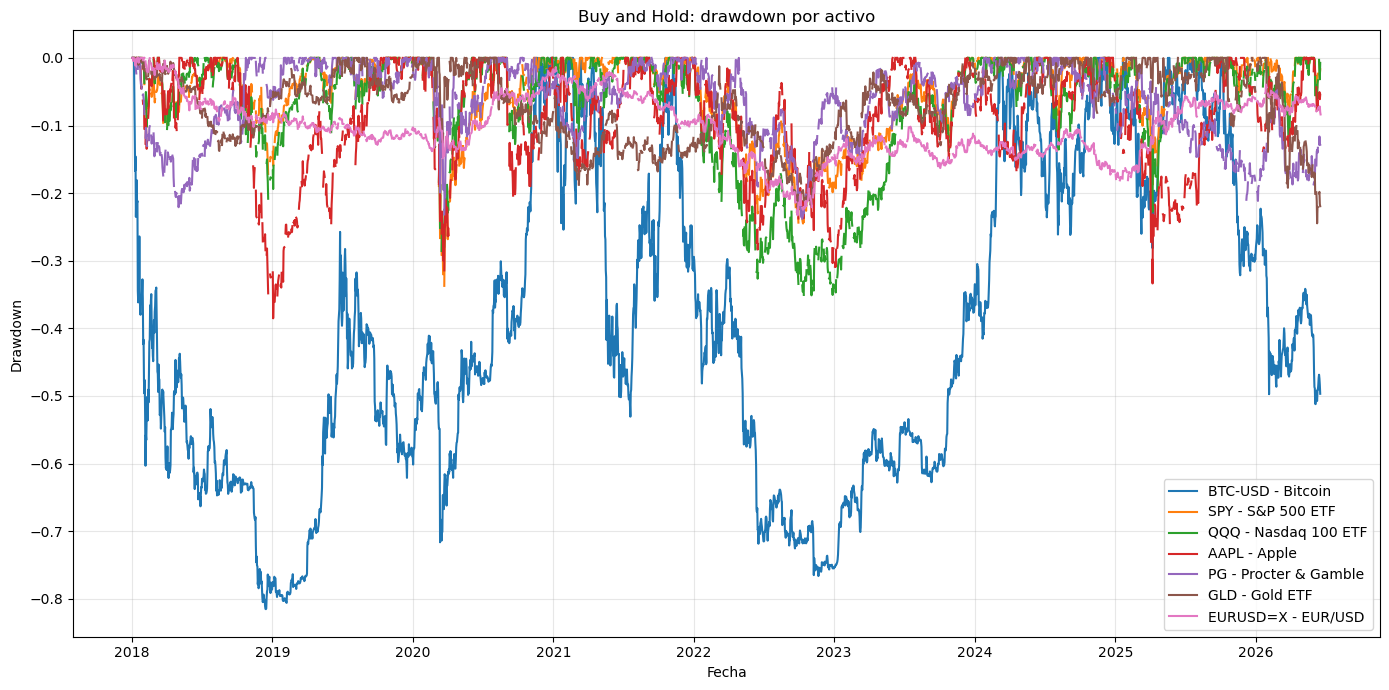

In [9]:
# ============================================================
# 3.4 DRAWDOWN BUY AND HOLD
# ============================================================

buy_hold_drawdown = buy_hold_equity / buy_hold_equity.cummax() - 1

plt.figure(figsize=(14, 7))

for ticker in buy_hold_drawdown.columns:
    plt.plot(
        buy_hold_drawdown.index,
        buy_hold_drawdown[ticker],
        label=f"{ticker} - {ASSETS[ticker]}"
    )

plt.title("Buy and Hold: drawdown por activo")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "buy_hold_drawdown.png", dpi=300)
plt.show()

La estrategia buy and hold permite establecer una referencia inicial para evaluar el comportamiento de cada activo sin aplicar reglas activas de entrada o salida. Los resultados muestran diferencias relevantes entre los activos analizados, tanto en términos de rentabilidad como de riesgo.

Bitcoin presenta una rentabilidad acumulada muy elevada, multiplicando por más de cuatro el capital inicial durante el periodo analizado. Sin embargo, este resultado viene acompañado de una volatilidad anualizada muy superior a la del resto de activos y de un máximo drawdown superior al 80%. Esto implica que, aunque la rentabilidad final es muy positiva, el inversor habría tenido que soportar caídas intermedias extremadamente severas.

Apple también muestra una rentabilidad acumulada muy elevada, incluso superior a la de Bitcoin en el periodo analizado, pero con una volatilidad y un drawdown notablemente inferiores. Esto se refleja en un ratio de Sharpe más alto, lo que indica una mejor relación entre rentabilidad y riesgo dentro del conjunto analizado.

Los ETFs SPY y QQQ ofrecen una referencia del mercado bursátil estadounidense. QQQ obtiene una mayor rentabilidad acumulada que SPY, pero también presenta mayor volatilidad y mayor drawdown, algo coherente con su mayor exposición al sector tecnológico y a empresas de crecimiento.

Procter & Gamble muestra un comportamiento más defensivo que los activos tecnológicos o Bitcoin. Su rentabilidad acumulada es positiva, pero claramente inferior a la de los activos más alcistas del periodo. Aun así, su inclusión resulta útil porque permite comprobar si las estrategias activas también funcionan en activos menos ligados al crecimiento tecnológico y con un comportamiento menos explosivo.

El oro, representado por GLD, ofrece una rentabilidad inferior a la de los principales activos de renta variable, pero con una volatilidad y un drawdown más contenidos. Por tanto, actúa como activo diversificador dentro del conjunto analizado.

Finalmente, EUR/USD presenta una rentabilidad acumulada muy reducida y un ratio de Sharpe cercano a cero. Este comportamiento es útil para el proyecto porque permite estudiar si las estrategias sistemáticas funcionan también en mercados con menor direccionalidad acumulada.

En conjunto, el benchmark buy and hold muestra que no basta con comparar rentabilidades finales. Una estrategia activa deberá evaluarse también por su capacidad para reducir drawdown, controlar volatilidad y mejorar la rentabilidad ajustada por riesgo.


# 4. Estrategia técnica basada en medias móviles

En esta sección se implementa una estrategia activa de seguimiento de tendencia basada en medias móviles. La idea es que, cuando una media móvil de corto plazo se sitúa por encima de una media móvil de largo plazo, el activo puede encontrarse en una fase alcista.

La estrategia se plantea bajo un enfoque **Long/Cash**:

$$
s_t =
\begin{cases}
1, & \text{si } MA_{corta}(t) > MA_{larga}(t) \\
0, & \text{si } MA_{corta}(t) \leq MA_{larga}(t)
\end{cases}
$$

donde \(s_t = 1\) indica estar invertido y \(s_t = 0\) indica permanecer en liquidez.

Para evitar sesgo de anticipación, el retorno de la estrategia se calcula aplicando la posición del periodo anterior al retorno observado en el periodo actual:

$$
r^{EMA}_t = s_{t-1} \cdot r_t
$$

La selección de parámetros se realiza únicamente en el periodo de entrenamiento. Se prueban distintas combinaciones de medias móviles y se elige la que obtiene mejor comportamiento medio según el ratio de Sharpe. Posteriormente, esa misma combinación se evalúa en el periodo de prueba.

In [10]:
# ============================================================
# 4.1 FUNCIONES AUXILIARES Y GRID DE PARÁMETROS
# ============================================================

# Periodos de entrenamiento y prueba
TRAIN_END_DATE = "2022-12-31"
TEST_START_DATE = "2023-01-01"

# Configuración de la estrategia
MOVING_AVERAGE_TYPE = "EMA"
TRANSACTION_COST = 0.0005

# Grid de parámetros a evaluar en train
SHORT_WINDOWS = [5, 10, 20, 30, 50]
LONG_WINDOWS = [50, 75, 100, 150, 200]


def compute_moving_average(series, window, ma_type="SMA"):
    """
    Calcula una media móvil simple o exponencial.
    """
    if ma_type.upper() == "SMA":
        return series.rolling(window=window).mean()
    elif ma_type.upper() == "EMA":
        return series.ewm(span=window, adjust=False).mean()
    else:
        raise ValueError("ma_type debe ser 'SMA' o 'EMA'.")


def build_equity_from_returns(returns, initial_capital=100.0):
    """
    Construye una curva de capital a partir de retornos logarítmicos.
    """
    return initial_capital * np.exp(returns.fillna(0).cumsum())


def evaluate_period_metrics(returns, initial_capital=100.0):
    """
    Calcula métricas de rendimiento rebasedas a 100 para un periodo concreto.
    """
    clean_returns = returns.dropna()
    equity = build_equity_from_returns(clean_returns, initial_capital=initial_capital)

    return calculate_performance_metrics(
        returns=clean_returns,
        equity_curve=equity,
        initial_capital=initial_capital
    )


def run_ma_long_cash_strategy(
    close_series,
    ticker,
    short_window,
    long_window,
    ma_type="EMA",
    transaction_cost=0.0005,
    initial_capital=100.0
):
    """
    Ejecuta una estrategia Long/Cash basada en cruce de medias móviles.
    """
    data = pd.DataFrame()
    data["close"] = close_series.dropna()
    data["log_return"] = np.log(data["close"] / data["close"].shift(1))

    data["ma_short"] = compute_moving_average(
        data["close"],
        window=short_window,
        ma_type=ma_type
    )

    data["ma_long"] = compute_moving_average(
        data["close"],
        window=long_window,
        ma_type=ma_type
    )

    # Señal Long/Cash y desplazamiento para evitar look-ahead bias
    data["signal"] = np.where(data["ma_short"] > data["ma_long"], 1, 0)
    data["position"] = data["signal"].shift(1).fillna(0)

    # Costes de transacción por entrada o salida
    data["position_change"] = data["position"].diff().abs().fillna(0)
    data["strategy_return_gross"] = data["position"] * data["log_return"]
    data["transaction_cost"] = data["position_change"] * transaction_cost
    data["strategy_return"] = data["strategy_return_gross"] - data["transaction_cost"]

    data["strategy_equity"] = build_equity_from_returns(
        data["strategy_return"],
        initial_capital=initial_capital
    )

    data["buy_hold_equity"] = build_equity_from_returns(
        data["log_return"],
        initial_capital=initial_capital
    )

    data["entry"] = data["position"].diff().fillna(0) == 1
    data["exit"] = data["position"].diff().fillna(0) == -1

    data["ticker"] = ticker
    data["short_window"] = short_window
    data["long_window"] = long_window
    data["ma_type"] = ma_type

    return data


# Grid de parámetros evaluado en train
parameter_grid = [
    {
        "short_window": short_window,
        "long_window": long_window
    }
    for short_window in SHORT_WINDOWS
    for long_window in LONG_WINDOWS
    if short_window < long_window
]

parameter_grid_df = pd.DataFrame(parameter_grid)

print(f"Grid de medias móviles creado: {len(parameter_grid_df)} combinaciones evaluadas.")

Grid de medias móviles creado: 24 combinaciones evaluadas.


In [11]:
# ============================================================
# 4.2 OPTIMIZACIÓN EN PERIODO DE ENTRENAMIENTO
# ============================================================

grid_results = []

for params in parameter_grid:
    short_window = params["short_window"]
    long_window = params["long_window"]

    asset_train_metrics = []

    for ticker in TICKERS:
        result = run_ma_long_cash_strategy(
            close_series=close_prices[ticker],
            ticker=ticker,
            short_window=short_window,
            long_window=long_window,
            ma_type=MOVING_AVERAGE_TYPE,
            transaction_cost=TRANSACTION_COST,
            initial_capital=INITIAL_CAPITAL
        )

        train_returns = result.loc[:TRAIN_END_DATE, "strategy_return"]

        metrics = evaluate_period_metrics(
            returns=train_returns,
            initial_capital=INITIAL_CAPITAL
        )

        metrics["ticker"] = ticker
        asset_train_metrics.append(metrics)

    asset_train_metrics_df = pd.DataFrame(asset_train_metrics)

    grid_results.append({
        "short_window": short_window,
        "long_window": long_window,
        "mean_train_total_return": asset_train_metrics_df["total_return"].mean(),
        "mean_train_annualized_return": asset_train_metrics_df["annualized_return"].mean(),
        "mean_train_volatility": asset_train_metrics_df["annualized_volatility"].mean(),
        "mean_train_sharpe": asset_train_metrics_df["sharpe_ratio"].mean(),
        "median_train_sharpe": asset_train_metrics_df["sharpe_ratio"].median(),
        "mean_train_max_drawdown": asset_train_metrics_df["max_drawdown"].mean(),
        "n_assets": asset_train_metrics_df["ticker"].nunique()
    })

grid_results_df = pd.DataFrame(grid_results)

# Criterio principal: mayor Sharpe medio en train.
# Criterio secundario: menor drawdown medio, es decir, drawdown menos negativo.
grid_results_ranked = grid_results_df.sort_values(
    by=["mean_train_sharpe", "mean_train_max_drawdown"],
    ascending=[False, False]
).reset_index(drop=True)

# Guardar ranking completo para trazabilidad
grid_results_ranked.round(4).to_csv(
    TABLES_DIR / "ma_parameter_optimization_train_full.csv",
    index=False
)

# Mejor combinación seleccionada en train
best_ma_params = grid_results_ranked.iloc[0]

BEST_SHORT_WINDOW = int(best_ma_params["short_window"])
BEST_LONG_WINDOW = int(best_ma_params["long_window"])

# Mostrar solo una tabla compacta
grid_results_display = grid_results_ranked[
    [
        "short_window",
        "long_window",
        "mean_train_sharpe",
        "median_train_sharpe",
        "mean_train_total_return",
        "mean_train_max_drawdown",
        "n_assets"
    ]
].head(5).copy()

cols_to_round = [
    "mean_train_sharpe",
    "median_train_sharpe",
    "mean_train_total_return",
    "mean_train_max_drawdown"
]

grid_results_display[cols_to_round] = grid_results_display[cols_to_round].round(4)

display(grid_results_display)

print(
    f"Parámetros seleccionados en train: "
    f"EMA corta = {BEST_SHORT_WINDOW}, EMA larga = {BEST_LONG_WINDOW}"
)

,short_window,long_window,mean_train_sharpe,median_train_sharpe,mean_train_total_return,mean_train_max_drawdown,n_assets
0,5,100,0.5176,0.6222,1.1377,-0.2410,7
1,20,75,0.5153,0.5776,1.0124,-0.2565,7
2,10,100,0.4715,0.5479,0.9735,-0.2425,7
3,5,150,0.4676,0.4743,0.9470,-0.2517,7
4,5,200,0.4636,0.4438,0.9476,-0.2444,7


Parámetros seleccionados en train: EMA corta = 5, EMA larga = 100


In [12]:
# ============================================================
# 4.3 EVALUACIÓN FINAL EN TRAIN Y TEST
# ============================================================

ma_results = {}
ma_metrics = []

for ticker in TICKERS:
    result = run_ma_long_cash_strategy(
        close_series=close_prices[ticker],
        ticker=ticker,
        short_window=BEST_SHORT_WINDOW,
        long_window=BEST_LONG_WINDOW,
        ma_type=MOVING_AVERAGE_TYPE,
        transaction_cost=TRANSACTION_COST,
        initial_capital=INITIAL_CAPITAL
    )

    ma_results[ticker] = result

    periods = {
        "Train": result.loc[:TRAIN_END_DATE, "strategy_return"],
        "Test": result.loc[TEST_START_DATE:, "strategy_return"]
    }

    for period_name, period_returns in periods.items():
        metrics = evaluate_period_metrics(
            returns=period_returns,
            initial_capital=INITIAL_CAPITAL
        )

        period_result = result.loc[period_returns.index]

        metrics["strategy"] = "EMA Long/Cash"
        metrics["period"] = period_name
        metrics["ticker"] = ticker
        metrics["asset_name"] = ASSETS[ticker]
        metrics["short_window"] = BEST_SHORT_WINDOW
        metrics["long_window"] = BEST_LONG_WINDOW
        metrics["ma_type"] = MOVING_AVERAGE_TYPE
        metrics["n_entries"] = int(period_result["entry"].sum())
        metrics["n_exits"] = int(period_result["exit"].sum())
        metrics["n_trades"] = metrics["n_entries"] + metrics["n_exits"]
        metrics["time_in_market"] = period_result["position"].mean()

        ma_metrics.append(metrics)

ma_metrics_df = pd.DataFrame(ma_metrics)

ma_metrics_df = ma_metrics_df[
    [
        "strategy",
        "period",
        "ticker",
        "asset_name",
        "short_window",
        "long_window",
        "ma_type",
        "final_equity",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "n_entries",
        "n_exits",
        "n_trades",
        "time_in_market",
        "n_observations"
    ]
]

# Guardar tabla completa para trazabilidad
ma_metrics_df.round(4).to_csv(
    TABLES_DIR / "ma_optimized_metrics_train_test_full.csv",
    index=False
)

# Tabla compacta para mostrar en el notebook
ma_metrics_display = ma_metrics_df[
    [
        "period",
        "ticker",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "time_in_market",
        "n_trades"
    ]
].copy()

cols_to_round = [
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "time_in_market"
]

ma_metrics_display[cols_to_round] = ma_metrics_display[cols_to_round].round(4)

display(ma_metrics_display)

print(
    f"Estrategia evaluada: {MOVING_AVERAGE_TYPE} "
    f"{BEST_SHORT_WINDOW}/{BEST_LONG_WINDOW}, coste={TRANSACTION_COST}"
)

,period,ticker,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,time_in_market,n_trades
0,Train,BTC-USD,4.6501,0.4145,0.4738,0.8748,-0.5329,0.4304,26
1,Test,BTC-USD,1.9428,0.3660,0.3646,1.0040,-0.2761,0.6656,30
2,Train,SPY,0.3214,0.0575,0.1234,0.4656,-0.1745,0.7085,26
3,Test,SPY,0.7004,0.1661,0.1144,1.4520,-0.0953,0.8687,13
4,Train,QQQ,0.6463,0.1051,0.1689,0.6222,-0.2075,0.7188,22
5,Test,QQQ,1.0946,0.2386,0.1645,1.4505,-0.1619,0.8733,17
6,Train,AAPL,1.6111,0.2122,0.2462,0.8616,-0.2233,0.7156,32
7,Test,AAPL,0.5666,0.1387,0.1824,0.7606,-0.2142,0.7154,27
8,Train,PG,0.6314,0.1031,0.1472,0.7002,-0.2173,0.7172,23
9,Test,PG,-0.1549,-0.0475,0.1216,-0.3909,-0.2428,0.5495,32


Estrategia evaluada: EMA 5/100, coste=0.0005


In [13]:
# ============================================================
# 4.4 BUY AND HOLD EN LOS MISMOS PERIODOS TRAIN/TEST
# ============================================================

bh_period_metrics = []

for ticker in TICKERS:
    asset_returns = log_returns[ticker].dropna()

    periods = {
        "Train": asset_returns.loc[:TRAIN_END_DATE],
        "Test": asset_returns.loc[TEST_START_DATE:]
    }

    for period_name, period_returns in periods.items():
        metrics = evaluate_period_metrics(
            returns=period_returns,
            initial_capital=INITIAL_CAPITAL
        )

        metrics["strategy"] = "Buy and Hold"
        metrics["period"] = period_name
        metrics["ticker"] = ticker
        metrics["asset_name"] = ASSETS[ticker]

        bh_period_metrics.append(metrics)

bh_period_metrics_df = pd.DataFrame(bh_period_metrics)

bh_period_metrics_df = bh_period_metrics_df[
    [
        "strategy",
        "period",
        "ticker",
        "asset_name",
        "final_equity",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "n_observations"
    ]
]

# Guardar tabla para trazabilidad, sin mostrarla en el notebook
bh_period_metrics_df.round(4).to_csv(
    TABLES_DIR / "buy_hold_metrics_train_test.csv",
    index=False
)

print("Métricas Buy and Hold calculadas para Train/Test.")

Métricas Buy and Hold calculadas para Train/Test.


In [14]:
# ============================================================
# 4.5 COMPARACIÓN FINAL EN TEST: BUY AND HOLD VS EMA
# ============================================================

bh_test = bh_period_metrics_df[
    bh_period_metrics_df["period"] == "Test"
].copy()

ma_test = ma_metrics_df[
    ma_metrics_df["period"] == "Test"
].copy()

# Columnas necesarias para la comparación
bh_test = bh_test[
    [
        "ticker",
        "asset_name",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown"
    ]
].rename(columns={
    "total_return": "bh_total_return",
    "annualized_return": "bh_annualized_return",
    "annualized_volatility": "bh_volatility",
    "sharpe_ratio": "bh_sharpe",
    "max_drawdown": "bh_max_drawdown"
})

ma_test = ma_test[
    [
        "ticker",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "time_in_market",
        "n_trades"
    ]
].rename(columns={
    "total_return": "ma_total_return",
    "annualized_return": "ma_annualized_return",
    "annualized_volatility": "ma_volatility",
    "sharpe_ratio": "ma_sharpe",
    "max_drawdown": "ma_max_drawdown"
})

ma_vs_bh_test_df = bh_test.merge(
    ma_test,
    on="ticker",
    how="inner"
)

# Diferencias principales
ma_vs_bh_test_df["return_diff"] = (
    ma_vs_bh_test_df["ma_total_return"] - ma_vs_bh_test_df["bh_total_return"]
)

ma_vs_bh_test_df["sharpe_diff"] = (
    ma_vs_bh_test_df["ma_sharpe"] - ma_vs_bh_test_df["bh_sharpe"]
)

ma_vs_bh_test_df["drawdown_improvement"] = (
    ma_vs_bh_test_df["ma_max_drawdown"] - ma_vs_bh_test_df["bh_max_drawdown"]
)

# Guardar tabla completa
ma_vs_bh_test_df.round(4).to_csv(
    TABLES_DIR / "comparison_test_buy_hold_vs_ema_full.csv",
    index=False
)

# Tabla compacta para mostrar
ma_vs_bh_test_display = ma_vs_bh_test_df[
    [
        "ticker",
        "asset_name",
        "bh_total_return",
        "ma_total_return",
        "return_diff",
        "bh_sharpe",
        "ma_sharpe",
        "sharpe_diff",
        "bh_max_drawdown",
        "ma_max_drawdown",
        "drawdown_improvement",
        "time_in_market",
        "n_trades"
    ]
].copy()

numeric_cols = ma_vs_bh_test_display.select_dtypes(include=[np.number]).columns
ma_vs_bh_test_display[numeric_cols] = ma_vs_bh_test_display[numeric_cols].round(4)

display(ma_vs_bh_test_display)

,ticker,asset_name,bh_total_return,ma_total_return,return_diff,bh_sharpe,ma_sharpe,sharpe_diff,bh_max_drawdown,ma_max_drawdown,drawdown_improvement,time_in_market,n_trades
0,BTC-USD,Bitcoin,2.7936,1.9428,-0.8509,0.9985,1.0040,0.0055,-0.5121,-0.2761,0.2360,0.6656,30
1,SPY,S&P 500 ETF,1.0368,0.7004,-0.3364,1.5143,1.4520,-0.0623,-0.1876,-0.0953,0.0923,0.8687,13
2,QQQ,Nasdaq 100 ETF,1.8351,1.0946,-0.7405,1.7632,1.4505,-0.3127,-0.2277,-0.1619,0.0658,0.8733,17
3,AAPL,Apple,1.3325,0.5666,-0.7660,1.0970,0.7606,-0.3364,-0.3336,-0.2142,0.1194,0.7154,27
4,PG,Procter & Gamble,0.0860,-0.1549,-0.2409,0.1408,-0.3909,-0.5317,-0.2115,-0.2428,-0.0312,0.5495,32
5,GLD,Gold ETF,1.2820,1.0931,-0.1889,1.3612,1.2845,-0.0767,-0.2446,-0.2544,-0.0098,0.8859,11
6,EURUSD=X,EUR/USD,0.0753,0.0285,-0.0469,0.2945,0.1408,-0.1537,-0.0884,-0.0629,0.0255,0.6344,23


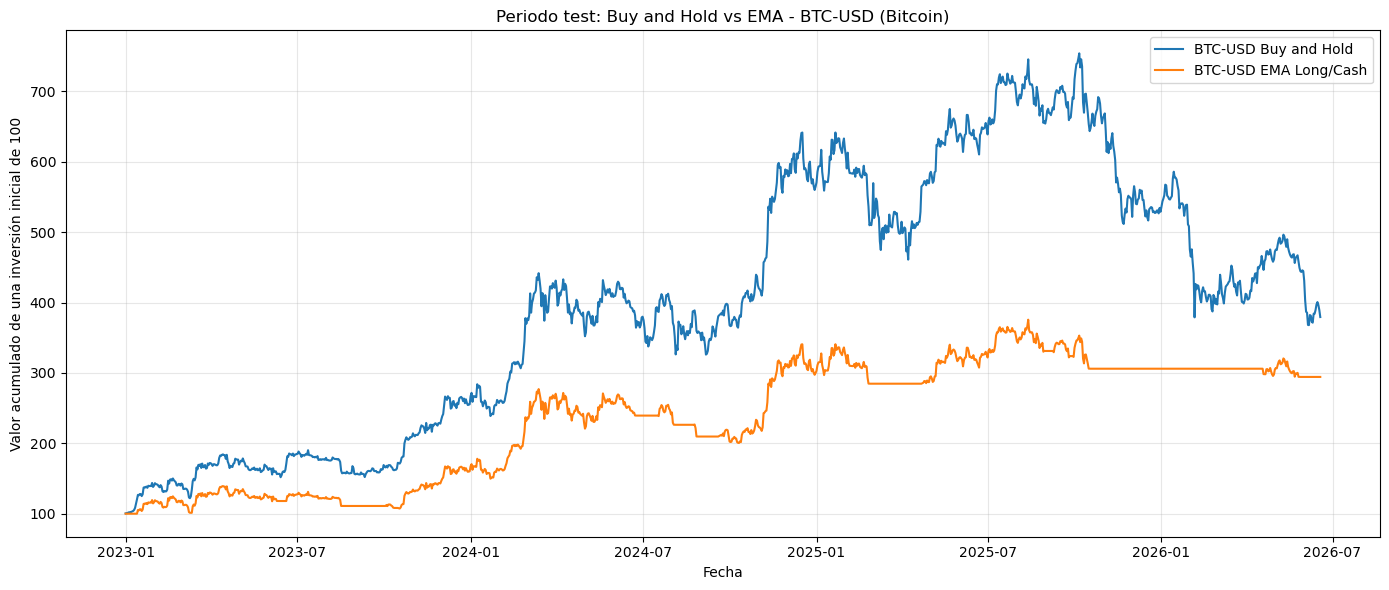

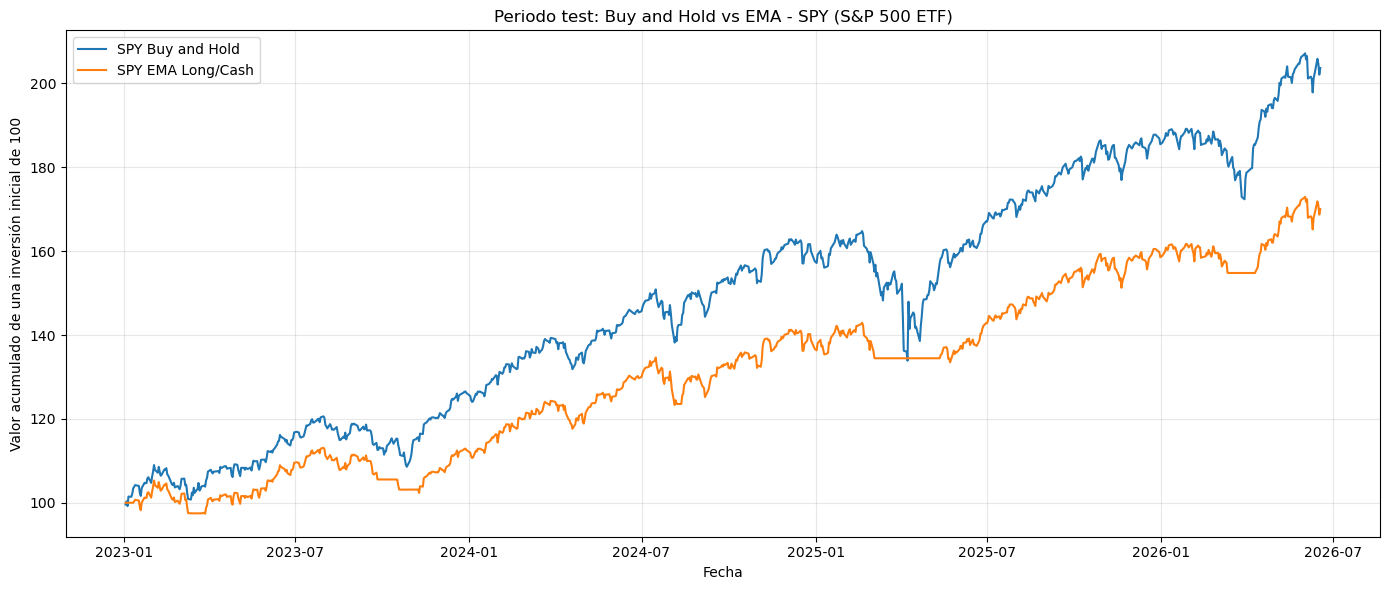

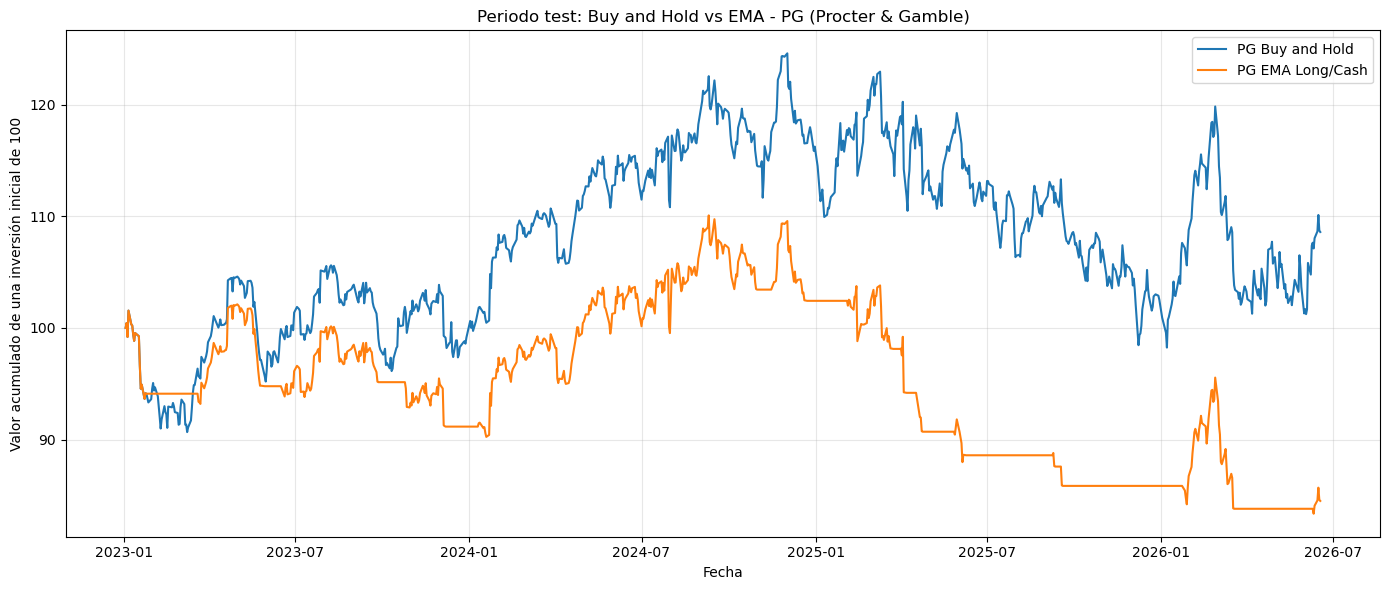

In [15]:
# ============================================================
# 4.6 CURVAS DE CAPITAL EN TEST: EJEMPLOS REPRESENTATIVOS
# ============================================================

selected_tickers_for_plot = ["BTC-USD", "SPY", "PG"]

for ticker in selected_tickers_for_plot:
    result = ma_results[ticker].loc[TEST_START_DATE:].copy()

    if result.empty:
        continue

    bh_test_equity = build_equity_from_returns(
        result["log_return"],
        initial_capital=INITIAL_CAPITAL
    )

    ma_test_equity = build_equity_from_returns(
        result["strategy_return"],
        initial_capital=INITIAL_CAPITAL
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        bh_test_equity.index,
        bh_test_equity,
        label=f"{ticker} Buy and Hold"
    )

    plt.plot(
        ma_test_equity.index,
        ma_test_equity,
        label=f"{ticker} EMA Long/Cash"
    )

    plt.title(f"Periodo test: Buy and Hold vs EMA - {ticker} ({ASSETS[ticker]})")
    plt.xlabel("Fecha")
    plt.ylabel("Valor acumulado de una inversión inicial de 100")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"test_bh_vs_ema_{ticker.replace('=', '').replace('-', '_')}.png"
    plt.savefig(FIGURES_DIR / filename, dpi=300)
    plt.show()

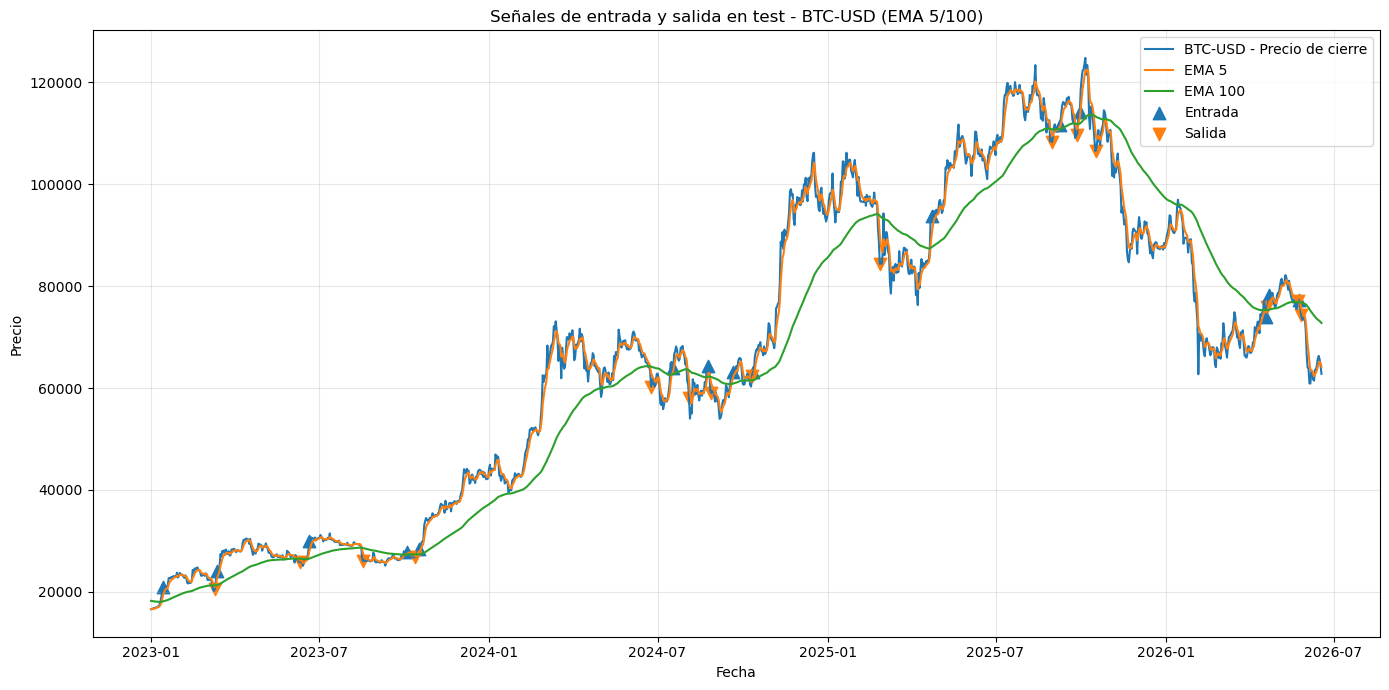

In [16]:
# ============================================================
# 4.6 SEÑALES DE ENTRADA Y SALIDA EN UN ACTIVO DE EJEMPLO
# ============================================================

EXAMPLE_TICKER = "BTC-USD"

example = ma_results[EXAMPLE_TICKER].loc[TEST_START_DATE:].copy()

plt.figure(figsize=(14, 7))

plt.plot(
    example.index,
    example["close"],
    label=f"{EXAMPLE_TICKER} - Precio de cierre"
)

plt.plot(
    example.index,
    example["ma_short"],
    label=f"{MOVING_AVERAGE_TYPE} {BEST_SHORT_WINDOW}"
)

plt.plot(
    example.index,
    example["ma_long"],
    label=f"{MOVING_AVERAGE_TYPE} {BEST_LONG_WINDOW}"
)

plt.scatter(
    example.loc[example["entry"]].index,
    example.loc[example["entry"], "close"],
    marker="^",
    s=80,
    label="Entrada"
)

plt.scatter(
    example.loc[example["exit"]].index,
    example.loc[example["exit"], "close"],
    marker="v",
    s=80,
    label="Salida"
)

plt.title(
    f"Señales de entrada y salida en test - {EXAMPLE_TICKER} "
    f"({MOVING_AVERAGE_TYPE} {BEST_SHORT_WINDOW}/{BEST_LONG_WINDOW})"
)
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / f"ma_signals_example_{EXAMPLE_TICKER.replace('-', '_')}.png",
    dpi=300
)
plt.show()

## Interpretación de la estrategia técnica optimizada

La optimización realizada en el periodo de entrenamiento selecciona como mejor combinación una media móvil exponencial corta de 5 periodos y una media móvil exponencial larga de 100 periodos. Esta combinación obtiene el mayor ratio de Sharpe medio en el conjunto de activos durante el periodo de entrenamiento, por lo que no se selecciona específicamente para maximizar el rendimiento de un único activo.

El uso de una EMA corta de 5 periodos permite que la estrategia reaccione con rapidez a cambios recientes en el precio, mientras que la EMA de 100 periodos actúa como filtro de tendencia de medio plazo. La estrategia permanece invertida únicamente cuando la media corta se sitúa por encima de la media larga, y pasa a liquidez cuando esta condición deja de cumplirse.

Los resultados en el periodo de prueba muestran un comportamiento heterogéneo. En Bitcoin, la estrategia obtiene una rentabilidad inferior a buy and hold, pero reduce de forma importante el máximo drawdown. Mientras buy and hold sufre una caída máxima superior al 50% en el periodo de prueba, la estrategia basada en medias móviles reduce ese drawdown hasta aproximadamente el 27,6%. Esto indica que, aunque la estrategia no captura toda la subida de Bitcoin, sí ayuda a limitar parte del riesgo bajista.

En los ETFs SPY y QQQ, la estrategia EMA Long/Cash no supera a buy and hold ni en rentabilidad total ni en ratio de Sharpe durante el periodo de prueba. Sin embargo, sí reduce el máximo drawdown en QQQ y mejora parcialmente el perfil defensivo de la cartera. En SPY, la estrategia obtiene una rentabilidad positiva, pero no logra batir a la referencia pasiva. Este resultado sugiere que, en índices bursátiles con una tendencia alcista persistente, una regla activa de medias móviles puede quedar fuera del mercado en tramos relevantes de subida.

En Apple, la estrategia tampoco consigue superar a buy and hold. Aunque reduce ligeramente el drawdown, pierde una parte relevante de la rentabilidad acumulada. Este resultado es importante porque muestra que una estrategia activa puede quedar fuera del mercado durante tramos positivos del activo, especialmente cuando se producen recuperaciones rápidas o movimientos alcistas después de caídas temporales.

El peor resultado se observa en Procter & Gamble, donde la estrategia obtiene rentabilidad negativa en el periodo de prueba, mientras que buy and hold sí obtiene rentabilidad positiva. Esto puede deberse a que una acción defensiva y menos tendencial genera más señales falsas para una estrategia basada en cruces de medias móviles. En este caso, la regla técnica no aporta valor y empeora tanto la rentabilidad como el drawdown.

En GLD, la estrategia obtiene una rentabilidad positiva y un ratio de Sharpe elevado, pero no supera a buy and hold. Además, el drawdown máximo es ligeramente más profundo que el de la estrategia pasiva. Por tanto, aunque la regla EMA captura parte del movimiento alcista del oro, no aporta una mejora clara frente a permanecer invertido durante todo el periodo.

Por último, en EUR/USD la estrategia obtiene una rentabilidad positiva muy reducida y un ratio de Sharpe inferior al de buy and hold. Esto confirma que el mercado de divisas analizado presenta menor direccionalidad acumulada y que una regla simple de medias móviles puede tener dificultades para generar valor en este contexto.

En conjunto, los resultados no permiten afirmar que la estrategia EMA 5/100 sea universalmente superior a buy and hold. Su principal aportación se observa en la reducción del drawdown en algunos activos, especialmente en Bitcoin y QQQ, pero a costa de sacrificar rentabilidad en mercados alcistas. La estrategia puede interpretarse como una herramienta defensiva de seguimiento de tendencia, no como una alternativa que mejore de forma generalizada la rentabilidad o el Sharpe frente a buy and hold. Su rendimiento depende claramente del tipo de activo y del régimen de mercado, lo que refuerza la necesidad de analizar posteriormente los resultados por contexto alcista, bajista y de volatilidad.


# 5. Estrategia predictiva basada en AutoARIMA

En esta sección se implementa una segunda estrategia activa basada en modelos de series temporales. A diferencia de la estrategia técnica anterior, que utiliza medias móviles para detectar tendencias observables, esta aproximación intenta estimar el signo del retorno futuro a partir de los retornos pasados.

Para cada activo, el orden del modelo ARIMA se selecciona mediante **AutoARIMA** utilizando únicamente el periodo de entrenamiento. La selección se realiza con un criterio de información, como el AIC, evitando utilizar datos del periodo de prueba durante la elección del modelo.

Dado que el modelo se aplica sobre retornos logarítmicos y no sobre precios, se fija (d=0). De forma simplificada, el modelo puede expresarse como:

$$
r_t = c + \sum_{i=1}^{p} \phi_i r_{t-i} + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j} + \varepsilon_t
$$

donde r_t es el retorno logarítmico, p representa el número de términos autorregresivos, q el número de términos de media móvil y varepsilon_t el término de error.

En el periodo de prueba se aplica una estrategia **walk-forward**: el modelo se reestima periódicamente usando una ventana móvil de retornos pasados y genera una predicción para el siguiente periodo.

La señal de trading sigue un enfoque **Long/Cash**:

$$
s_t =
\begin{cases}
1, & \text{si } \hat{r}_{t+1} > 0 \\
0, & \text{si } \hat{r}_{t+1} \leq 0
\end{cases}
$$

donde \hat{r}_{t+1} es el retorno esperado para el siguiente periodo. La estrategia permanece invertida cuando la predicción es positiva y queda en liquidez cuando la predicción es nula o negativa. No se utilizan posiciones cortas ni apalancamiento.

Para evitar sesgo de anticipación, la señal generada con información pasada se aplica al retorno del periodo siguiente:

$$
r^{\text{ARIMA}}_t = s_{t-1} \cdot r_t
$$


La estrategia se evalúa con los mismos costes de transacción aproximados que la estrategia técnica, manteniendo una comparación homogénea frente a Buy and Hold y frente a la estrategia EMA Long/Cash.


In [17]:
# ============================================================
# 5. ESTRATEGIA PREDICTIVA BASADA EN AUTOARIMA
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Activos evaluados con la estrategia predictiva
ARIMA_TICKERS = TICKERS

# Configuración de AutoARIMA para seleccionar el orden en train
ARIMA_MAX_P = 3
ARIMA_MAX_Q = 3
ARIMA_D = 0
ARIMA_INFORMATION_CRITERION = "aic"

# Configuración walk-forward en test
ARIMA_WINDOW = 252
ARIMA_REBALANCE_EVERY = 20
ARIMA_FORECAST_THRESHOLD = 0.0

print(
    f"AutoARIMA configurado: d={ARIMA_D}, max_p={ARIMA_MAX_P}, "
    f"max_q={ARIMA_MAX_Q}, criterio={ARIMA_INFORMATION_CRITERION}, "
    f"ventana={ARIMA_WINDOW}, rebalanceo={ARIMA_REBALANCE_EVERY}"
)

AutoARIMA configurado: d=0, max_p=3, max_q=3, criterio=aic, ventana=252, rebalanceo=20


In [18]:
# ============================================================
# 5.1 SELECCIÓN DEL ORDEN ARIMA EN TRAIN CON AUTOARIMA
# ============================================================

def select_arima_order_train(
    returns,
    max_p=3,
    max_q=3,
    d=0,
    information_criterion="aic",
    min_observations=100
):
    """
    Selecciona el orden ARIMA en train usando AutoARIMA.
    """
    clean_returns = (
        returns
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(clean_returns) < min_observations:
        raise ValueError(
            f"No hay observaciones suficientes para AutoARIMA: "
            f"{len(clean_returns)} < {min_observations}"
        )

    model = auto_arima(
        clean_returns,
        start_p=0,
        start_q=0,
        max_p=max_p,
        max_q=max_q,
        d=d,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        information_criterion=information_criterion,
        trace=False
    )

    return {
        "selected_order": tuple(int(x) for x in model.order),
        "aic": float(model.aic()),
        "bic": float(model.bic()),
        "selection_method": f"auto_arima_train_{information_criterion}"
    }


arima_order_results = []

for ticker in ARIMA_TICKERS:
    train_returns = log_returns[ticker].loc[:TRAIN_END_DATE].dropna()

    try:
        order_info = select_arima_order_train(
            returns=train_returns,
            max_p=ARIMA_MAX_P,
            max_q=ARIMA_MAX_Q,
            d=ARIMA_D,
            information_criterion=ARIMA_INFORMATION_CRITERION
        )
    except Exception as exc:
        raise RuntimeError(
            f"AutoARIMA ha fallado para {ticker}. "
            "Revisa la serie temporal o la configuración del modelo."
        ) from exc

    arima_order_results.append({
        "ticker": ticker,
        "asset_name": ASSETS[ticker],
        "selected_order": order_info["selected_order"],
        "aic": order_info["aic"],
        "bic": order_info["bic"],
        "selection_method": order_info["selection_method"],
        "n_train_observations": len(train_returns)
    })

arima_order_df = pd.DataFrame(arima_order_results)

# Guardar tabla completa
arima_order_df.to_csv(
    TABLES_DIR / "arima_selected_orders_train.csv",
    index=False
)

# Mostrar tabla compacta
arima_order_display = arima_order_df.copy()
arima_order_display[["aic", "bic"]] = arima_order_display[["aic", "bic"]].round(2)

display(arima_order_display)

,ticker,asset_name,selected_order,aic,bic,selection_method,n_train_observations
0,BTC-USD,Bitcoin,"(2, 0, 0)",-6662.13,-6645.60,auto_arima_train_aic,1825
1,SPY,S&P 500 ETF,"(2, 0, 0)",-7271.18,-7255.76,auto_arima_train_aic,1258
2,QQQ,Nasdaq 100 ETF,"(1, 0, 0)",-6775.19,-6764.91,auto_arima_train_aic,1258
3,AAPL,Apple,"(1, 0, 0)",-6147.75,-6132.34,auto_arima_train_aic,1258
4,PG,Procter & Gamble,"(1, 0, 0)",-7225.11,-7209.70,auto_arima_train_aic,1258
5,GLD,Gold ETF,"(0, 0, 0)",-8264.59,-8259.45,auto_arima_train_aic,1258
6,EURUSD=X,EUR/USD,"(0, 0, 1)",-10363.80,-10353.46,auto_arima_train_aic,1303


In [19]:
# ============================================================
# 5.2 WALK-FORWARD ARIMA LONG/CASH Y EVALUACIÓN EN TEST
# ============================================================

def run_arima_walk_forward_strategy(
    close_series,
    ticker,
    arima_order,
    test_start_date,
    window=252,
    rebalance_every=20,
    forecast_threshold=0.0,
    transaction_cost=0.0005,
    initial_capital=100.0
):
    """
    Ejecuta una estrategia ARIMA Long/Cash en test mediante walk-forward.
    """
    data = pd.DataFrame()
    data["close"] = close_series.dropna()
    data["log_return"] = np.log(data["close"] / data["close"].shift(1))

    data["forecast"] = np.nan
    data["raw_signal"] = np.nan
    data["forecast_failed"] = False

    test_dates = data.loc[test_start_date:].index

    for counter, current_date in enumerate(test_dates):

        if counter % rebalance_every != 0:
            continue

        current_position = data.index.get_loc(current_date)

        if current_position < window:
            continue

        train_window = data["log_return"].iloc[
            current_position - window:current_position
        ].dropna()

        if len(train_window) < window * 0.8:
            continue

        try:
            model = ARIMA(
                train_window,
                order=arima_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit()
            forecast_value = float(np.asarray(fitted_model.forecast(steps=1))[0])

        except Exception:
            forecast_value = 0.0
            data.loc[current_date, "forecast_failed"] = True

        data.loc[current_date, "forecast"] = forecast_value
        data.loc[current_date, "raw_signal"] = int(forecast_value > forecast_threshold)

    # La señal se mantiene hasta la siguiente reestimación
    data["signal"] = data["raw_signal"].ffill().fillna(0)

    # Posición aplicada al periodo siguiente para evitar look-ahead bias
    data["position"] = data["signal"].shift(1).fillna(0)

    data["position_change"] = data["position"].diff().abs().fillna(0)
    data["transaction_cost"] = data["position_change"] * transaction_cost

    data["strategy_return_gross"] = data["position"] * data["log_return"]
    data["strategy_return"] = data["strategy_return_gross"] - data["transaction_cost"]

    data["strategy_equity"] = build_equity_from_returns(
        data["strategy_return"],
        initial_capital=initial_capital
    )

    data["buy_hold_equity"] = build_equity_from_returns(
        data["log_return"],
        initial_capital=initial_capital
    )

    data["entry"] = data["position"].diff().fillna(0) == 1
    data["exit"] = data["position"].diff().fillna(0) == -1

    data["ticker"] = ticker
    data["arima_order"] = str(arima_order)

    return data


arima_results = {}
arima_metrics = []

for ticker in ARIMA_TICKERS:
    selected_order = arima_order_df.loc[
        arima_order_df["ticker"] == ticker,
        "selected_order"
    ].iloc[0]

    result = run_arima_walk_forward_strategy(
        close_series=close_prices[ticker],
        ticker=ticker,
        arima_order=selected_order,
        test_start_date=TEST_START_DATE,
        window=ARIMA_WINDOW,
        rebalance_every=ARIMA_REBALANCE_EVERY,
        forecast_threshold=ARIMA_FORECAST_THRESHOLD,
        transaction_cost=TRANSACTION_COST,
        initial_capital=INITIAL_CAPITAL
    )

    arima_results[ticker] = result

    test_result = result.loc[TEST_START_DATE:].copy()

    metrics = evaluate_period_metrics(
        returns=test_result["strategy_return"],
        initial_capital=INITIAL_CAPITAL
    )

    metrics["strategy"] = "ARIMA Long/Cash"
    metrics["period"] = "Test"
    metrics["ticker"] = ticker
    metrics["asset_name"] = ASSETS[ticker]
    metrics["arima_order"] = str(selected_order)
    metrics["n_rebalances"] = int(test_result["forecast"].notna().sum())
    metrics["n_failed_forecasts"] = int(test_result["forecast_failed"].sum())
    metrics["n_entries"] = int(test_result["entry"].sum())
    metrics["n_exits"] = int(test_result["exit"].sum())
    metrics["n_trades"] = metrics["n_entries"] + metrics["n_exits"]
    metrics["time_in_market"] = test_result["position"].mean()

    arima_metrics.append(metrics)

arima_metrics_df = pd.DataFrame(arima_metrics)

arima_metrics_df = arima_metrics_df[
    [
        "strategy",
        "period",
        "ticker",
        "asset_name",
        "arima_order",
        "final_equity",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "n_rebalances",
        "n_failed_forecasts",
        "n_entries",
        "n_exits",
        "n_trades",
        "time_in_market",
        "n_observations"
    ]
]

# Guardar tabla completa
arima_metrics_df.round(4).to_csv(
    TABLES_DIR / "arima_long_cash_metrics_test_full.csv",
    index=False
)

# Tabla compacta para mostrar en el notebook
arima_metrics_display = arima_metrics_df[
    [
        "ticker",
        "asset_name",
        "arima_order",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "time_in_market",
        "n_rebalances",
        "n_failed_forecasts",
        "n_trades"
    ]
].copy()

numeric_cols = arima_metrics_display.select_dtypes(include=[np.number]).columns
arima_metrics_display[numeric_cols] = arima_metrics_display[numeric_cols].round(4)

display(arima_metrics_display)

,ticker,asset_name,arima_order,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,time_in_market,n_rebalances,n_failed_forecasts,n_trades
0,BTC-USD,Bitcoin,"(2, 0, 0)",2.2784,0.4093,0.4046,1.0117,-0.3317,0.7589,64,0,16
1,SPY,S&P 500 ETF,"(2, 0, 0)",0.8064,0.1867,0.1112,1.6790,-0.0888,0.7684,44,0,13
2,QQQ,Nasdaq 100 ETF,"(1, 0, 0)",0.8734,0.1992,0.1842,1.0819,-0.2277,0.8376,44,0,5
3,AAPL,Apple,"(1, 0, 0)",0.3416,0.0888,0.2210,0.4017,-0.3336,0.6763,44,0,13
4,PG,Procter & Gamble,"(1, 0, 0)",0.0917,0.0257,0.1210,0.2124,-0.1176,0.5991,44,0,6
5,GLD,Gold ETF,"(0, 0, 0)",0.9715,0.2171,0.1945,1.1160,-0.2446,0.9528,44,0,3
6,EURUSD=X,EUR/USD,"(0, 0, 1)",-0.0381,-0.0112,0.0534,-0.2088,-0.0838,0.6878,45,0,13


In [20]:
# ============================================================
# 5.4 PREPARACIÓN DE RESULTADOS PARA COMPARACIÓN GLOBAL
# ============================================================

metric_columns = [
    "strategy",
    "period",
    "ticker",
    "asset_name",
    "final_equity",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_observations"
]

bh_test_comparison = bh_period_metrics_df[
    (bh_period_metrics_df["period"] == "Test") &
    (bh_period_metrics_df["ticker"].isin(ARIMA_TICKERS))
][metric_columns].copy()

ma_test_comparison = ma_metrics_df[
    (ma_metrics_df["period"] == "Test") &
    (ma_metrics_df["ticker"].isin(ARIMA_TICKERS))
][metric_columns].copy()

arima_test_comparison = arima_metrics_df[metric_columns].copy()

all_strategies_test_comparison = pd.concat(
    [
        bh_test_comparison,
        ma_test_comparison,
        arima_test_comparison
    ],
    axis=0,
    ignore_index=True
)

all_strategies_test_comparison.round(4).to_csv(
    TABLES_DIR / "comparison_test_all_strategies.csv",
    index=False
)

print("Resultados de test preparados para la comparación global.")

Resultados de test preparados para la comparación global.


## Interpretación de la estrategia ARIMA y comparación en test

La estrategia ARIMA introduce un enfoque predictivo frente a la estrategia técnica basada en medias móviles. Mientras que la estrategia EMA Long/Cash utiliza una regla de seguimiento de tendencia observable, ARIMA intenta estimar el retorno esperado del siguiente periodo a partir de la estructura temporal de los retornos pasados.

En el periodo de prueba, los resultados muestran que ARIMA no supera de forma generalizada a buy and hold. Sin embargo, sí obtiene resultados competitivos en algunos activos concretos. En Bitcoin, ARIMA alcanza una rentabilidad acumulada inferior a buy and hold, pero consigue un ratio de Sharpe ligeramente superior y reduce de forma importante el máximo drawdown. Esto indica que, aunque la estrategia no captura toda la subida del activo, mejora parcialmente la relación entre rentabilidad y riesgo.

En SPY, buy and hold obtiene la mayor rentabilidad acumulada, lo que confirma la dificultad de superar a un índice amplio durante un periodo alcista. No obstante, ARIMA Long/Cash obtiene el mejor ratio de Sharpe y el menor drawdown dentro de las estrategias comparadas. Por tanto, en este activo ARIMA no mejora la rentabilidad absoluta, pero sí ofrece un comportamiento más eficiente desde el punto de vista ajustado por riesgo.

En QQQ, buy and hold obtiene los mejores resultados en rentabilidad acumulada y ratio de Sharpe. Esto sugiere que, durante el periodo de prueba, permanecer invertido en este ETF tecnológico habría sido más eficiente que aplicar una estrategia activa basada en predicción ARIMA o en cruces de medias móviles. En este caso, las estrategias activas habrían perdido parte de los tramos alcistas del activo.

En Apple, buy and hold también supera claramente a las estrategias activas. Tanto EMA como ARIMA quedan por debajo en rentabilidad y Sharpe, lo que indica que las reglas activas habrían dejado fuera del mercado parte de los movimientos alcistas del activo.

En Procter & Gamble, ARIMA obtiene el mejor resultado relativo. Aunque no alcanza una rentabilidad muy elevada, mejora tanto a buy and hold como a la estrategia EMA en términos de Sharpe y drawdown. Este resultado es relevante porque PG había sido un activo problemático para la estrategia de medias móviles, mostrando que un enfoque predictivo puede comportarse mejor en determinados activos menos tendenciales.

En GLD, buy and hold mantiene el mejor ratio de Sharpe, aunque ARIMA y EMA también consiguen rentabilidades positivas. Esto indica que las estrategias activas capturan parte del movimiento alcista del oro, pero no logran mejorar claramente a la estrategia pasiva en términos ajustados por riesgo.

Finalmente, en EUR/USD el resultado de ARIMA es el peor de las tres estrategias. El modelo genera un ratio de Sharpe negativo (−0,21), lo que indica que la estrategia pierde valor en términos ajustados por riesgo. Buy and Hold obtiene una rentabilidad reducida pero positiva y un Sharpe de 0,29, mientras que EMA Long/Cash también queda por encima de ARIMA. Este resultado confirma la dificultad de aplicar modelos de series temporales a activos con baja direccionalidad acumulada y escasa estructura temporal predecible.

En conjunto, los resultados muestran que ninguna estrategia activa domina de forma universal a buy and hold. La estrategia ARIMA aporta valor en algunos activos, especialmente en Bitcoin, SPY y Procter & Gamble, aunque por motivos distintos: en Bitcoin y SPY mejora la relación entre rentabilidad y riesgo, mientras que en PG ofrece el mejor comportamiento relativo frente a las otras estrategias. La estrategia EMA optimizada, por su parte, destaca más por su capacidad de reducir drawdown en algunos activos que por maximizar la rentabilidad.

Estos resultados refuerzan una de las ideas principales del proyecto: una estrategia de trading debe evaluarse no solo por su rentabilidad acumulada, sino también por su comportamiento fuera de muestra, su drawdown, su volatilidad y su capacidad de generalización a distintos activos.


# 6. Comparación global de estrategias

Una vez evaluadas las tres aproximaciones principales, se realiza una comparación conjunta de resultados en el periodo de prueba:

* Buy and Hold.
* EMA Long/Cash optimizada.
* ARIMA Long/Cash con orden seleccionado mediante AutoARIMA.

La comparación se realiza exclusivamente sobre el periodo de test, ya que este tramo no se ha utilizado para optimizar los parámetros de la estrategia técnica ni para seleccionar el orden inicial del modelo ARIMA. De esta forma, la evaluación se aproxima mejor a un escenario fuera de muestra.

El objetivo de esta sección no es identificar una estrategia ganadora de forma absoluta, sino analizar qué enfoque presenta mejor comportamiento según el activo y la métrica considerada. Para ello se comparan la rentabilidad total, la rentabilidad anualizada, la volatilidad anualizada, el ratio de Sharpe y el máximo drawdown.

El ratio de Sharpe se utiliza como criterio principal porque resume la relación entre rentabilidad y riesgo. No obstante, también se analiza el máximo drawdown, ya que una estrategia puede obtener buena rentabilidad acumulada pero sufrir caídas intermedias relevantes.


In [21]:
# ============================================================
# 6.1 COMPARACIÓN GLOBAL DE ESTRATEGIAS EN TEST
# ============================================================

global_comparison = all_strategies_test_comparison.copy()

# Orden lógico de las estrategias
strategy_order = {
    "Buy and Hold": 1,
    "EMA Long/Cash": 2,
    "ARIMA Long/Cash": 3
}

global_comparison["strategy_order"] = global_comparison["strategy"].map(strategy_order)

global_comparison = global_comparison.sort_values(
    by=["ticker", "strategy_order"]
).reset_index(drop=True)

# Guardar tabla completa para trazabilidad
global_comparison.drop(columns="strategy_order").round(4).to_csv(
    TABLES_DIR / "global_strategy_comparison_test_full.csv",
    index=False
)

# Tabla compacta para mostrar
global_comparison_display = global_comparison[
    [
        "ticker",
        "asset_name",
        "strategy",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown"
    ]
].copy()

numeric_cols = [
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown"
]

global_comparison_display[numeric_cols] = (
    global_comparison_display[numeric_cols].round(4)
)

display(global_comparison_display)

,ticker,asset_name,strategy,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
0,AAPL,Apple,Buy and Hold,1.3325,0.2778,0.2532,1.0970,-0.3336
1,AAPL,Apple,EMA Long/Cash,0.5666,0.1387,0.1824,0.7606,-0.2142
2,AAPL,Apple,ARIMA Long/Cash,0.3416,0.0888,0.2210,0.4017,-0.3336
3,BTC-USD,Bitcoin,Buy and Hold,2.7936,0.4700,0.4707,0.9985,-0.5121
4,BTC-USD,Bitcoin,EMA Long/Cash,1.9428,0.3660,0.3646,1.0040,-0.2761
5,BTC-USD,Bitcoin,ARIMA Long/Cash,2.2784,0.4093,0.4046,1.0117,-0.3317
6,EURUSD=X,EUR/USD,Buy and Hold,0.0753,0.0212,0.0720,0.2945,-0.0884
7,EURUSD=X,EUR/USD,EMA Long/Cash,0.0285,0.0081,0.0578,0.1408,-0.0629
8,EURUSD=X,EUR/USD,ARIMA Long/Cash,-0.0381,-0.0112,0.0534,-0.2088,-0.0838
9,GLD,Gold ETF,Buy and Hold,1.2820,0.2697,0.1981,1.3612,-0.2446


In [22]:
# ============================================================
# 6.2 MEJOR ESTRATEGIA POR ACTIVO SEGÚN SHARPE
# ============================================================

best_by_sharpe = (
    global_comparison
    .sort_values(["ticker", "sharpe_ratio"], ascending=[True, False])
    .groupby("ticker")
    .head(1)
    .reset_index(drop=True)
)

# Guardar tabla completa
best_by_sharpe.drop(columns=["strategy_order"], errors="ignore").round(4).to_csv(
    TABLES_DIR / "best_strategy_by_sharpe_test_full.csv",
    index=False
)

# Tabla compacta para mostrar
best_by_sharpe_display = best_by_sharpe[
    [
        "ticker",
        "asset_name",
        "strategy",
        "total_return",
        "annualized_return",
        "sharpe_ratio",
        "max_drawdown"
    ]
].copy()

numeric_cols_best = [
    "total_return",
    "annualized_return",
    "sharpe_ratio",
    "max_drawdown"
]

best_by_sharpe_display[numeric_cols_best] = (
    best_by_sharpe_display[numeric_cols_best].round(4)
)

display(best_by_sharpe_display)

,ticker,asset_name,strategy,total_return,annualized_return,sharpe_ratio,max_drawdown
0,AAPL,Apple,Buy and Hold,1.3325,0.2778,1.0970,-0.3336
1,BTC-USD,Bitcoin,ARIMA Long/Cash,2.2784,0.4093,1.0117,-0.3317
2,EURUSD=X,EUR/USD,Buy and Hold,0.0753,0.0212,0.2945,-0.0884
3,GLD,Gold ETF,Buy and Hold,1.2820,0.2697,1.3612,-0.2446
4,PG,Procter & Gamble,ARIMA Long/Cash,0.0917,0.0257,0.2124,-0.1176
5,QQQ,Nasdaq 100 ETF,Buy and Hold,1.8351,0.3520,1.7632,-0.2277
6,SPY,S&P 500 ETF,ARIMA Long/Cash,0.8064,0.1867,1.6790,-0.0888


In [23]:
# ============================================================
# 6.3 RESUMEN DE MEJORES ESTRATEGIAS POR MÉTRICA
# ============================================================

# Mejor estrategia por rentabilidad total
best_by_return = (
    global_comparison
    .sort_values(["ticker", "total_return"], ascending=[True, False])
    .groupby("ticker")
    .head(1)
    .reset_index(drop=True)
)

# Mejor estrategia por menor drawdown
# Como max_drawdown es negativo, el mejor valor es el más cercano a 0.
best_by_drawdown = (
    global_comparison
    .sort_values(["ticker", "max_drawdown"], ascending=[True, False])
    .groupby("ticker")
    .head(1)
    .reset_index(drop=True)
)

# Guardar tablas completas
best_by_return.drop(columns=["strategy_order"], errors="ignore").round(4).to_csv(
    TABLES_DIR / "best_strategy_by_return_test_full.csv",
    index=False
)

best_by_drawdown.drop(columns=["strategy_order"], errors="ignore").round(4).to_csv(
    TABLES_DIR / "best_strategy_by_drawdown_test_full.csv",
    index=False
)

# Tabla compacta: ganador por activo y métrica
winners_by_metric = best_by_sharpe[
    ["ticker", "asset_name", "strategy", "sharpe_ratio"]
].rename(columns={
    "strategy": "best_sharpe_strategy",
    "sharpe_ratio": "best_sharpe"
})

winners_by_metric = winners_by_metric.merge(
    best_by_return[["ticker", "strategy", "total_return"]].rename(columns={
        "strategy": "best_return_strategy",
        "total_return": "best_total_return"
    }),
    on="ticker",
    how="left"
)

winners_by_metric = winners_by_metric.merge(
    best_by_drawdown[["ticker", "strategy", "max_drawdown"]].rename(columns={
        "strategy": "best_drawdown_strategy",
        "max_drawdown": "best_max_drawdown"
    }),
    on="ticker",
    how="left"
)

numeric_cols_winners = [
    "best_sharpe",
    "best_total_return",
    "best_max_drawdown"
]

winners_by_metric[numeric_cols_winners] = (
    winners_by_metric[numeric_cols_winners].round(4)
)

display(winners_by_metric)

winners_by_metric.to_csv(
    TABLES_DIR / "best_strategy_by_metric_test.csv",
    index=False
)

# Resumen de victorias por estrategia
strategy_names = ["Buy and Hold", "EMA Long/Cash", "ARIMA Long/Cash"]

wins_summary = pd.DataFrame({"strategy": strategy_names})

wins_summary["best_sharpe_count"] = (
    wins_summary["strategy"]
    .map(best_by_sharpe["strategy"].value_counts())
    .fillna(0)
    .astype(int)
)

wins_summary["best_return_count"] = (
    wins_summary["strategy"]
    .map(best_by_return["strategy"].value_counts())
    .fillna(0)
    .astype(int)
)

wins_summary["best_drawdown_count"] = (
    wins_summary["strategy"]
    .map(best_by_drawdown["strategy"].value_counts())
    .fillna(0)
    .astype(int)
)

display(wins_summary)

wins_summary.to_csv(
    TABLES_DIR / "strategy_wins_summary_test.csv",
    index=False
)

,ticker,asset_name,best_sharpe_strategy,best_sharpe,best_return_strategy,best_total_return,best_drawdown_strategy,best_max_drawdown
0,AAPL,Apple,Buy and Hold,1.0970,Buy and Hold,1.3325,EMA Long/Cash,-0.2142
1,BTC-USD,Bitcoin,ARIMA Long/Cash,1.0117,Buy and Hold,2.7936,EMA Long/Cash,-0.2761
2,EURUSD=X,EUR/USD,Buy and Hold,0.2945,Buy and Hold,0.0753,EMA Long/Cash,-0.0629
3,GLD,Gold ETF,Buy and Hold,1.3612,Buy and Hold,1.2820,ARIMA Long/Cash,-0.2446
4,PG,Procter & Gamble,ARIMA Long/Cash,0.2124,ARIMA Long/Cash,0.0917,ARIMA Long/Cash,-0.1176
5,QQQ,Nasdaq 100 ETF,Buy and Hold,1.7632,Buy and Hold,1.8351,EMA Long/Cash,-0.1619
6,SPY,S&P 500 ETF,ARIMA Long/Cash,1.6790,Buy and Hold,1.0368,ARIMA Long/Cash,-0.0888


,strategy,best_sharpe_count,best_return_count,best_drawdown_count
0,Buy and Hold,4,6,0
1,EMA Long/Cash,0,0,4
2,ARIMA Long/Cash,3,1,3


In [24]:
# ============================================================
# 6.4 MÉTRICAS MEDIAS POR ESTRATEGIA EN TEST
# ============================================================

strategy_average_metrics = (
    global_comparison
    .groupby("strategy")
    .agg(
        mean_total_return=("total_return", "mean"),
        median_total_return=("total_return", "median"),
        mean_annualized_return=("annualized_return", "mean"),
        mean_annualized_volatility=("annualized_volatility", "mean"),
        mean_sharpe=("sharpe_ratio", "mean"),
        median_sharpe=("sharpe_ratio", "median"),
        mean_max_drawdown=("max_drawdown", "mean"),
        median_max_drawdown=("max_drawdown", "median"),
        n_assets=("ticker", "nunique")
    )
    .reset_index()
)

# Orden lógico de estrategias
strategy_order = {
    "Buy and Hold": 1,
    "EMA Long/Cash": 2,
    "ARIMA Long/Cash": 3
}

strategy_average_metrics["strategy_order"] = (
    strategy_average_metrics["strategy"].map(strategy_order)
)

strategy_average_metrics = (
    strategy_average_metrics
    .sort_values("strategy_order")
    .drop(columns="strategy_order")
    .reset_index(drop=True)
)

# Guardar tabla completa
strategy_average_metrics.round(4).to_csv(
    TABLES_DIR / "strategy_average_metrics_test_full.csv",
    index=False
)

# Tabla compacta para mostrar
strategy_average_display = strategy_average_metrics[
    [
        "strategy",
        "mean_total_return",
        "mean_annualized_return",
        "mean_sharpe",
        "median_sharpe",
        "mean_max_drawdown",
        "n_assets"
    ]
].copy()

cols_to_round = [
    "mean_total_return",
    "mean_annualized_return",
    "mean_sharpe",
    "median_sharpe",
    "mean_max_drawdown"
]

strategy_average_display[cols_to_round] = (
    strategy_average_display[cols_to_round].round(4)
)

display(strategy_average_display)

,strategy,mean_total_return,mean_annualized_return,mean_sharpe,median_sharpe,mean_max_drawdown,n_assets
0,Buy and Hold,1.2059,0.2348,1.0242,1.0970,-0.2579,7
1,EMA Long/Cash,0.7530,0.1583,0.8145,1.0040,-0.1868,7
2,ARIMA Long/Cash,0.7607,0.1594,0.7563,1.0117,-0.2040,7


In [25]:
# ============================================================
# 6.5 TABLA PIVOT PRINCIPAL: SHARPE POR ACTIVO Y ESTRATEGIA
# ============================================================

strategy_column_order = ["Buy and Hold", "EMA Long/Cash", "ARIMA Long/Cash"]

sharpe_pivot = (
    global_comparison
    .pivot(index="ticker", columns="strategy", values="sharpe_ratio")
    .reindex(columns=strategy_column_order)
)

return_pivot = (
    global_comparison
    .pivot(index="ticker", columns="strategy", values="total_return")
    .reindex(columns=strategy_column_order)
)

drawdown_pivot = (
    global_comparison
    .pivot(index="ticker", columns="strategy", values="max_drawdown")
    .reindex(columns=strategy_column_order)
)

# Guardar pivots completos
sharpe_pivot.round(4).to_csv(TABLES_DIR / "pivot_sharpe_by_asset_strategy.csv")
return_pivot.round(4).to_csv(TABLES_DIR / "pivot_return_by_asset_strategy.csv")
drawdown_pivot.round(4).to_csv(TABLES_DIR / "pivot_drawdown_by_asset_strategy.csv")

# Mostrar solo el pivot principal
display(sharpe_pivot.round(4))

strategy,Buy and Hold,EMA Long/Cash,ARIMA Long/Cash
ticker,,,
AAPL,1.0970,0.7606,0.4017
BTC-USD,0.9985,1.0040,1.0117
EURUSD=X,0.2945,0.1408,-0.2088
GLD,1.3612,1.2845,1.1160
PG,0.1408,-0.3909,0.2124
QQQ,1.7632,1.4505,1.0819
SPY,1.5143,1.4520,1.6790


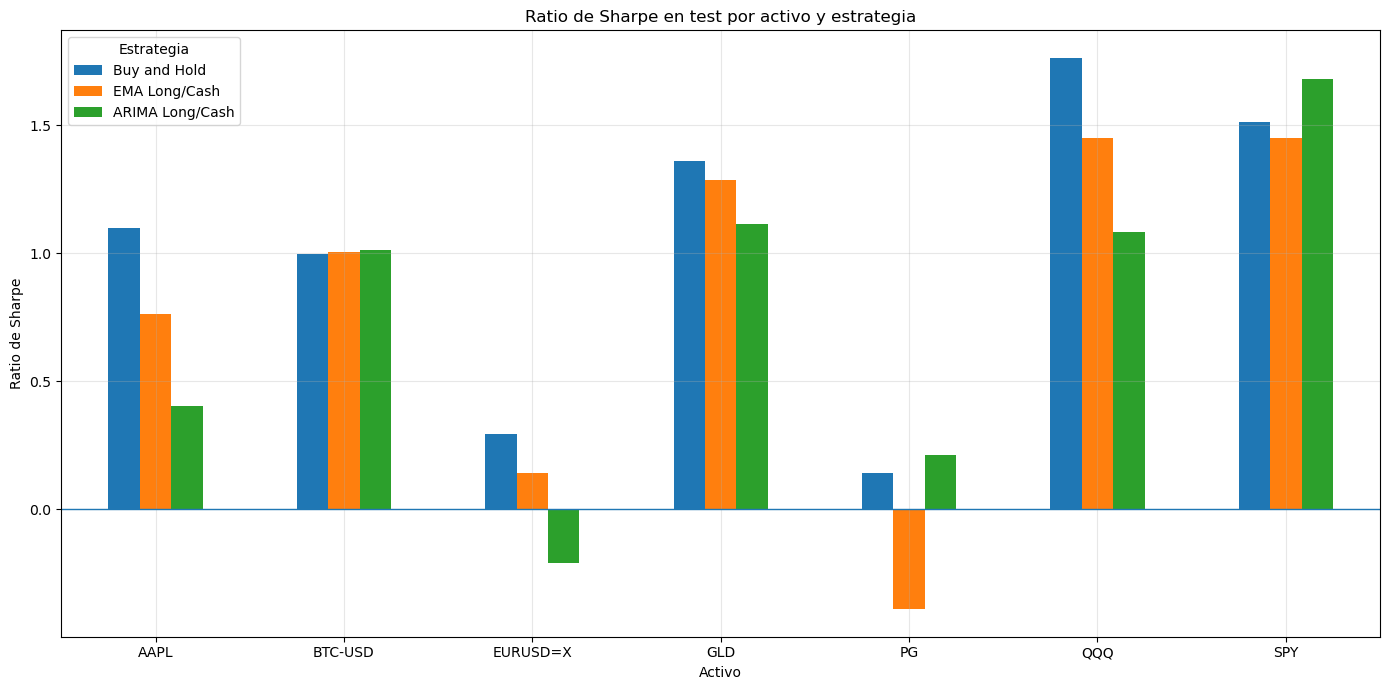

In [26]:
# ============================================================
# 6.6 GRÁFICO PRINCIPAL: SHARPE POR ACTIVO Y ESTRATEGIA
# ============================================================

ax = sharpe_pivot.plot(
    kind="bar",
    figsize=(14, 7),
    rot=0
)

ax.set_title("Ratio de Sharpe en test por activo y estrategia")
ax.set_xlabel("Activo")
ax.set_ylabel("Ratio de Sharpe")
ax.axhline(0, linewidth=1)
ax.grid(True, alpha=0.3)
ax.legend(title="Estrategia")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "comparison_sharpe_by_asset_strategy.png",
    dpi=300
)
plt.show()

## Comparación global

La comparación global permite extraer una conclusión central del proyecto: ninguna estrategia domina de forma universal en todos los activos y bajo todas las métricas. El rendimiento depende del tipo de activo analizado y del criterio utilizado para evaluar la estrategia.

En términos de rentabilidad total, buy and hold obtiene el mejor resultado en seis de los siete activos analizados. Esto ocurre especialmente en activos que han mostrado una tendencia alcista clara durante el periodo de prueba, como Bitcoin, QQQ, Apple, GLD y SPY. Este resultado indica que, en mercados fuertemente alcistas, permanecer invertido puede ser difícil de superar mediante estrategias activas simples.

En términos de ratio de Sharpe, buy and hold obtiene el mejor resultado en cuatro de los siete activos analizados: QQQ, Apple, GLD y EUR/USD. Esto muestra que la estrategia pasiva no solo destaca por rentabilidad acumulada, sino que también ofrece una relación rentabilidad-riesgo competitiva en varios activos.

La estrategia ARIMA Long/Cash obtiene el mejor ratio de Sharpe en tres activos: Bitcoin, SPY y Procter & Gamble. En Bitcoin, ARIMA no supera a buy and hold en rentabilidad total, pero mejora ligeramente la rentabilidad ajustada por riesgo y reduce el drawdown máximo. En SPY, buy and hold obtiene mayor rentabilidad acumulada, pero ARIMA presenta mejor Sharpe y menor drawdown. En Procter & Gamble, ARIMA es la mejor estrategia tanto por Sharpe como por rentabilidad total y drawdown, lo que resulta relevante porque la estrategia técnica basada en medias móviles había mostrado un mal comportamiento en este activo. 
En EUR/USD, la estrategia ARIMA obtiene un ratio de Sharpe negativo (−0,21), el peor resultado entre todas las estrategias y activos del análisis. Buy and Hold, aunque con una rentabilidad acumulada muy reducida, obtiene el mejor Sharpe del grupo (0,29). Este activo ilustra con claridad que los enfoques sistemáticos pueden fallar cuando el mercado parece de tendencia y de estructura temporal predecible.

La estrategia EMA Long/Cash optimizada no aparece como la mejor estrategia por rentabilidad ni por Sharpe en ningún activo, pero destaca en la reducción del drawdown. Es la estrategia con menor pérdida máxima en cuatro de los siete activos: Bitcoin, QQQ, Apple y EUR/USD. Esto permite interpretarla como una estrategia más defensiva, orientada a limitar caídas, aunque a cambio de sacrificar parte de la rentabilidad en mercados alcistas.

El análisis medio por estrategia confirma esta lectura. Buy and hold presenta la mayor rentabilidad media y el mayor Sharpe medio, pero también el peor drawdown medio. La estrategia EMA muestra menor rentabilidad media, pero también el drawdown medio más reducido. ARIMA se sitúa en una posición intermedia, con resultados especialmente buenos en algunos activos concretos, pero sin una superioridad generalizada.

En conjunto, los resultados apoyan una conclusión prudente: las estrategias activas pueden aportar valor en determinados contextos, especialmente como mecanismos de control de riesgo o en activos concretos, pero no sustituyen de forma sistemática a buy and hold. La elección de estrategia dependerá del objetivo principal: maximizar rentabilidad, reducir drawdown o mejorar la rentabilidad ajustada por riesgo.


# 7. Análisis por régimen de mercado

Hasta este punto, las estrategias se han comparado de forma agregada durante todo el periodo de prueba. Sin embargo, su comportamiento puede variar según el contexto de mercado. Por ello, en esta sección se analiza el rendimiento condicionado a distintos regímenes.

Se consideran dos tipos de régimen:

* **Régimen tendencial**: alcista, bajista o lateral.
* **Régimen de volatilidad**: baja, media o alta volatilidad.

El régimen tendencial se aproxima mediante una media móvil de largo plazo. Se clasifica un periodo como alcista cuando el precio se sitúa por encima de la media móvil y esta presenta pendiente positiva. Se clasifica como bajista cuando el precio está por debajo de la media y la pendiente es negativa. El resto de casos se considera lateral o de transición:

$$
\text{Alcista si } P_t > MA_{200}(t) \text{ y } \Delta MA_{200}(t) > 0
$$

$$
\text{Bajista si } P_t < MA_{200}(t) \text{ y } \Delta MA_{200}(t) < 0
$$

$$
\text{Lateral en el resto de casos}
$$

El régimen de volatilidad se calcula mediante la desviación típica móvil de los retornos logarítmicos. Posteriormente, los periodos se clasifican en baja, media o alta volatilidad utilizando los percentiles 25 y 75 de la volatilidad observada en el periodo de prueba.

Este análisis no se utiliza para optimizar nuevas reglas de inversión, sino como una herramienta descriptiva para interpretar los resultados. Su objetivo es comprobar si las estrategias activas aportan más valor en determinados entornos, por ejemplo reduciendo pérdidas en mercados bajistas o controlando mejor el riesgo en fases de mayor volatilidad.


In [27]:
# ============================================================
# 7.1 CLASIFICACIÓN DE REGÍMENES Y DATASETS DE RETORNOS
# ============================================================

REGIME_MA_WINDOW = 200
REGIME_SLOPE_WINDOW = 20
VOLATILITY_WINDOW = 30


def classify_market_regimes(
    close_series,
    test_start_date,
    ma_window=200,
    slope_window=20,
    volatility_window=30
):
    """
    Clasifica cada fecha según régimen tendencial y régimen de volatilidad.
    """
    data = pd.DataFrame()
    data["close"] = close_series.dropna()
    data["log_return"] = np.log(data["close"] / data["close"].shift(1))

    # Régimen tendencial
    data["regime_ma"] = data["close"].rolling(ma_window).mean()
    data["regime_ma_slope"] = data["regime_ma"] - data["regime_ma"].shift(slope_window)

    data["trend_regime"] = "Lateral"

    bullish_condition = (
        (data["close"] > data["regime_ma"]) &
        (data["regime_ma_slope"] > 0)
    )

    bearish_condition = (
        (data["close"] < data["regime_ma"]) &
        (data["regime_ma_slope"] < 0)
    )

    data.loc[bullish_condition, "trend_regime"] = "Alcista"
    data.loc[bearish_condition, "trend_regime"] = "Bajista"

    # Régimen de volatilidad
    data["rolling_volatility"] = (
        data["log_return"]
        .rolling(volatility_window)
        .std()
    )

    test_volatility = data.loc[test_start_date:, "rolling_volatility"].dropna()

    low_vol_threshold = test_volatility.quantile(0.25)
    high_vol_threshold = test_volatility.quantile(0.75)

    data["volatility_regime"] = "Volatilidad media"

    data.loc[
        data["rolling_volatility"] <= low_vol_threshold,
        "volatility_regime"
    ] = "Baja volatilidad"

    data.loc[
        data["rolling_volatility"] >= high_vol_threshold,
        "volatility_regime"
    ] = "Alta volatilidad"

    data["combined_regime"] = (
        data["trend_regime"] + " / " + data["volatility_regime"]
    )

    return data


def calculate_conditional_metrics(
    returns,
    observations_per_year,
    initial_capital=100.0
):
    """
    Calcula métricas descriptivas para retornos condicionados a un régimen.
    """
    clean_returns = returns.dropna()

    if len(clean_returns) == 0:
        return {
            "total_return": np.nan,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
            "n_observations": 0
        }

    total_return = np.exp(clean_returns.sum()) - 1
    annualized_return = np.exp(clean_returns.mean() * observations_per_year) - 1
    annualized_volatility = clean_returns.std() * np.sqrt(observations_per_year)

    sharpe_ratio = (
        annualized_return / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    equity_curve = initial_capital * np.exp(clean_returns.cumsum())
    drawdown = equity_curve / equity_curve.cummax() - 1

    return {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": drawdown.min(),
        "n_observations": len(clean_returns)
    }


regime_data = {}
strategy_returns_by_asset = {}

for ticker in TICKERS:
    regimes = classify_market_regimes(
        close_series=close_prices[ticker],
        test_start_date=TEST_START_DATE,
        ma_window=REGIME_MA_WINDOW,
        slope_window=REGIME_SLOPE_WINDOW,
        volatility_window=VOLATILITY_WINDOW
    )

    regime_data[ticker] = regimes

    strategy_returns_by_asset[ticker] = {
        "Buy and Hold": log_returns[ticker].dropna(),
        "EMA Long/Cash": ma_results[ticker]["strategy_return"],
        "ARIMA Long/Cash": arima_results[ticker]["strategy_return"]
    }

print(
    f"Regímenes calculados: MA={REGIME_MA_WINDOW}, "
    f"pendiente={REGIME_SLOPE_WINDOW}, volatilidad={VOLATILITY_WINDOW}"
)

Regímenes calculados: MA=200, pendiente=20, volatilidad=30


In [28]:
# ============================================================
# 7.2 CONTEO DE OBSERVACIONES POR RÉGIMEN
# ============================================================

regime_counts = []

for ticker in TICKERS:
    test_regimes = regime_data[ticker].loc[TEST_START_DATE:].copy()
    
    trend_counts = test_regimes["trend_regime"].value_counts()
    volatility_counts = test_regimes["volatility_regime"].value_counts()
    
    for regime, count in trend_counts.items():
        regime_counts.append({
            "ticker": ticker,
            "asset_name": ASSETS[ticker],
            "regime_type": "Tendencia",
            "regime": regime,
            "n_observations": count
        })
    
    for regime, count in volatility_counts.items():
        regime_counts.append({
            "ticker": ticker,
            "asset_name": ASSETS[ticker],
            "regime_type": "Volatilidad",
            "regime": regime,
            "n_observations": count
        })

regime_counts_df = pd.DataFrame(regime_counts)

display(regime_counts_df.sort_values(["regime_type", "ticker", "regime"]))

regime_counts_df.to_csv(TABLES_DIR / "regime_observation_counts.csv", index=False)

,ticker,asset_name,regime_type,regime,n_observations
18,AAPL,Apple,Tendencia,Alcista,625
19,AAPL,Apple,Tendencia,Bajista,128
20,AAPL,Apple,Tendencia,Lateral,115
0,BTC-USD,Bitcoin,Tendencia,Alcista,811
1,BTC-USD,Bitcoin,Tendencia,Bajista,231
2,BTC-USD,Bitcoin,Tendencia,Lateral,223
35,EURUSD=X,EUR/USD,Tendencia,Alcista,511
37,EURUSD=X,EUR/USD,Tendencia,Bajista,177
36,EURUSD=X,EUR/USD,Tendencia,Lateral,212
30,GLD,Gold ETF,Tendencia,Alcista,780


In [29]:
# ============================================================
# 7.3 MÉTRICAS POR RÉGIMEN, ACTIVO Y ESTRATEGIA
# ============================================================

regime_metrics = []

regime_definitions = {
    "Tendencia": (
        "trend_regime",
        ["Alcista", "Bajista", "Lateral"]
    ),
    "Volatilidad": (
        "volatility_regime",
        ["Baja volatilidad", "Volatilidad media", "Alta volatilidad"]
    )
}

for ticker in TICKERS:
    regimes = regime_data[ticker].loc[TEST_START_DATE:].copy()

    if len(regimes) < 2:
        continue

    # Observaciones por año empíricas del activo en test
    years = (regimes.index[-1] - regimes.index[0]).days / 365.25
    observations_per_year = len(regimes) / years if years > 0 else 252

    for strategy_name, returns in strategy_returns_by_asset[ticker].items():
        returns_test = returns.loc[TEST_START_DATE:].dropna()

        analysis_df = (
            returns_test
            .to_frame("strategy_return")
            .join(
                regimes[["trend_regime", "volatility_regime"]],
                how="inner"
            )
        )

        for regime_type, (regime_column, regime_values) in regime_definitions.items():
            for regime in regime_values:
                regime_returns = analysis_df.loc[
                    analysis_df[regime_column] == regime,
                    "strategy_return"
                ]

                metrics = calculate_conditional_metrics(
                    regime_returns,
                    observations_per_year=observations_per_year,
                    initial_capital=INITIAL_CAPITAL
                )

                metrics.update({
                    "ticker": ticker,
                    "asset_name": ASSETS[ticker],
                    "strategy": strategy_name,
                    "regime_type": regime_type,
                    "regime": regime
                })

                regime_metrics.append(metrics)

regime_metrics_df = pd.DataFrame(regime_metrics)

regime_metrics_df = regime_metrics_df[
    [
        "ticker",
        "asset_name",
        "strategy",
        "regime_type",
        "regime",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "n_observations"
    ]
]

# Guardar tabla completa para trazabilidad
regime_metrics_df.round(4).to_csv(
    TABLES_DIR / "strategy_metrics_by_market_regime_full.csv",
    index=False
)

# Resumen compacto para mostrar
regime_summary = (
    regime_metrics_df
    .groupby(["regime_type", "regime", "strategy"])
    .agg(
        mean_total_return=("total_return", "mean"),
        mean_sharpe=("sharpe_ratio", "mean"),
        mean_max_drawdown=("max_drawdown", "mean"),
        total_observations=("n_observations", "sum")
    )
    .reset_index()
)

cols_to_round = [
    "mean_total_return",
    "mean_sharpe",
    "mean_max_drawdown"
]

regime_summary[cols_to_round] = regime_summary[cols_to_round].round(4)

display(regime_summary)

regime_summary.to_csv(
    TABLES_DIR / "strategy_metrics_by_market_regime_summary.csv",
    index=False
)

,regime_type,regime,strategy,mean_total_return,mean_sharpe,mean_max_drawdown,total_observations
0,Tendencia,Alcista,ARIMA Long/Cash,0.9760,1.3017,-0.1407,4681
1,Tendencia,Alcista,Buy and Hold,1.4362,1.6337,-0.1272,4681
2,Tendencia,Alcista,EMA Long/Cash,0.7457,1.0071,-0.1545,4681
3,Tendencia,Bajista,ARIMA Long/Cash,0.0088,0.8380,-0.0608,855
4,Tendencia,Bajista,Buy and Hold,0.0069,2.0185,-0.1382,855
5,Tendencia,Bajista,EMA Long/Cash,-0.0542,-2.3909,-0.0542,855
6,Tendencia,Lateral,ARIMA Long/Cash,-0.0965,-0.9814,-0.1681,969
7,Tendencia,Lateral,Buy and Hold,-0.0386,-0.1204,-0.2021,969
8,Tendencia,Lateral,EMA Long/Cash,0.0508,1.1446,-0.0924,969
9,Volatilidad,Alta volatilidad,ARIMA Long/Cash,0.0911,0.8649,-0.1756,1627


In [30]:
# ============================================================
# 7.4 RESUMEN MEDIO POR RÉGIMEN Y ESTRATEGIA
# ============================================================

regime_strategy_summary = (
    regime_metrics_df
    .groupby(["regime_type", "regime", "strategy"])
    .agg(
        mean_total_return=("total_return", "mean"),
        mean_annualized_return=("annualized_return", "mean"),
        mean_sharpe=("sharpe_ratio", "mean"),
        mean_max_drawdown=("max_drawdown", "mean"),
        total_observations=("n_observations", "sum"),
        n_assets=("ticker", "nunique")
    )
    .reset_index()
)

# Guardar tabla completa
regime_strategy_summary.round(4).to_csv(
    TABLES_DIR / "regime_strategy_summary_full.csv",
    index=False
)

# Tabla compacta para mostrar
regime_strategy_display = regime_strategy_summary[
    [
        "regime_type",
        "regime",
        "strategy",
        "mean_total_return",
        "mean_annualized_return",
        "mean_sharpe",
        "mean_max_drawdown",
        "total_observations",
        "n_assets"
    ]
].copy()

cols_to_round = [
    "mean_total_return",
    "mean_annualized_return",
    "mean_sharpe",
    "mean_max_drawdown"
]

regime_strategy_display[cols_to_round] = (
    regime_strategy_display[cols_to_round].round(4)
)

display(regime_strategy_display)

,regime_type,regime,strategy,mean_total_return,mean_annualized_return,mean_sharpe,mean_max_drawdown,total_observations,n_assets
0,Tendencia,Alcista,ARIMA Long/Cash,0.9760,0.2790,1.3017,-0.1407,4681,7
1,Tendencia,Alcista,Buy and Hold,1.4362,0.3808,1.6337,-0.1272,4681,7
2,Tendencia,Alcista,EMA Long/Cash,0.7457,0.2211,1.0071,-0.1545,4681,7
3,Tendencia,Bajista,ARIMA Long/Cash,0.0088,0.1028,0.8380,-0.0608,855,7
4,Tendencia,Bajista,Buy and Hold,0.0069,0.3928,2.0185,-0.1382,855,7
5,Tendencia,Bajista,EMA Long/Cash,-0.0542,-0.1433,-2.3909,-0.0542,855,7
6,Tendencia,Lateral,ARIMA Long/Cash,-0.0965,-0.1948,-0.9814,-0.1681,969,7
7,Tendencia,Lateral,Buy and Hold,-0.0386,-0.0607,-0.1204,-0.2021,969,7
8,Tendencia,Lateral,EMA Long/Cash,0.0508,0.1765,1.1446,-0.0924,969,7
9,Volatilidad,Alta volatilidad,ARIMA Long/Cash,0.0911,0.1079,0.8649,-0.1756,1627,7


In [31]:
# ============================================================
# 7.5 MEJOR ESTRATEGIA POR RÉGIMEN SEGÚN SHARPE MEDIO
# ============================================================

best_strategy_by_regime = (
    regime_strategy_summary
    .sort_values(
        ["regime_type", "regime", "mean_sharpe"],
        ascending=[True, True, False]
    )
    .groupby(["regime_type", "regime"])
    .head(1)
    .reset_index(drop=True)
)

# Guardar tabla completa
best_strategy_by_regime.round(4).to_csv(
    TABLES_DIR / "best_strategy_by_regime_full.csv",
    index=False
)

# Tabla compacta para mostrar
best_strategy_by_regime_display = best_strategy_by_regime[
    [
        "regime_type",
        "regime",
        "strategy",
        "mean_total_return",
        "mean_annualized_return",
        "mean_sharpe",
        "mean_max_drawdown",
        "total_observations",
        "n_assets"
    ]
].copy()

cols_to_round = [
    "mean_total_return",
    "mean_annualized_return",
    "mean_sharpe",
    "mean_max_drawdown"
]

best_strategy_by_regime_display[cols_to_round] = (
    best_strategy_by_regime_display[cols_to_round].round(4)
)

display(best_strategy_by_regime_display)

,regime_type,regime,strategy,mean_total_return,mean_annualized_return,mean_sharpe,mean_max_drawdown,total_observations,n_assets
0,Tendencia,Alcista,Buy and Hold,1.4362,0.3808,1.6337,-0.1272,4681,7
1,Tendencia,Bajista,Buy and Hold,0.0069,0.3928,2.0185,-0.1382,855,7
2,Tendencia,Lateral,EMA Long/Cash,0.0508,0.1765,1.1446,-0.0924,969,7
3,Volatilidad,Alta volatilidad,Buy and Hold,0.2172,0.2590,1.1129,-0.2058,1627,7
4,Volatilidad,Baja volatilidad,Buy and Hold,0.1576,0.1865,1.6592,-0.1089,1627,7
5,Volatilidad,Volatilidad media,Buy and Hold,0.5860,0.2819,1.0880,-0.1772,3251,7


In [32]:
# ============================================================
# 7.6 PIVOTS DE SHARPE MEDIO POR RÉGIMEN
# ============================================================

strategy_order = ["Buy and Hold", "EMA Long/Cash", "ARIMA Long/Cash"]

trend_order = ["Alcista", "Lateral", "Bajista"]
volatility_order = ["Baja volatilidad", "Volatilidad media", "Alta volatilidad"]

trend_sharpe_pivot = (
    regime_strategy_summary[
        regime_strategy_summary["regime_type"] == "Tendencia"
    ]
    .pivot(
        index="regime",
        columns="strategy",
        values="mean_sharpe"
    )
    .reindex(index=trend_order, columns=strategy_order)
)

volatility_sharpe_pivot = (
    regime_strategy_summary[
        regime_strategy_summary["regime_type"] == "Volatilidad"
    ]
    .pivot(
        index="regime",
        columns="strategy",
        values="mean_sharpe"
    )
    .reindex(index=volatility_order, columns=strategy_order)
)

trend_sharpe_pivot.round(4).to_csv(
    TABLES_DIR / "pivot_trend_regime_mean_sharpe.csv"
)

volatility_sharpe_pivot.round(4).to_csv(
    TABLES_DIR / "pivot_volatility_regime_mean_sharpe.csv"
)

print("Sharpe medio por régimen tendencial:")
display(trend_sharpe_pivot.round(4))

print("Sharpe medio por régimen de volatilidad:")
display(volatility_sharpe_pivot.round(4))

Sharpe medio por régimen tendencial:


strategy,Buy and Hold,EMA Long/Cash,ARIMA Long/Cash
regime,,,
Alcista,1.6337,1.0071,1.3017
Lateral,-0.1204,1.1446,-0.9814
Bajista,2.0185,-2.3909,0.8380


Sharpe medio por régimen de volatilidad:


strategy,Buy and Hold,EMA Long/Cash,ARIMA Long/Cash
regime,,,
Baja volatilidad,1.6592,1.6307,1.4882
Volatilidad media,1.0880,0.9026,0.7855
Alta volatilidad,1.1129,0.5249,0.8649


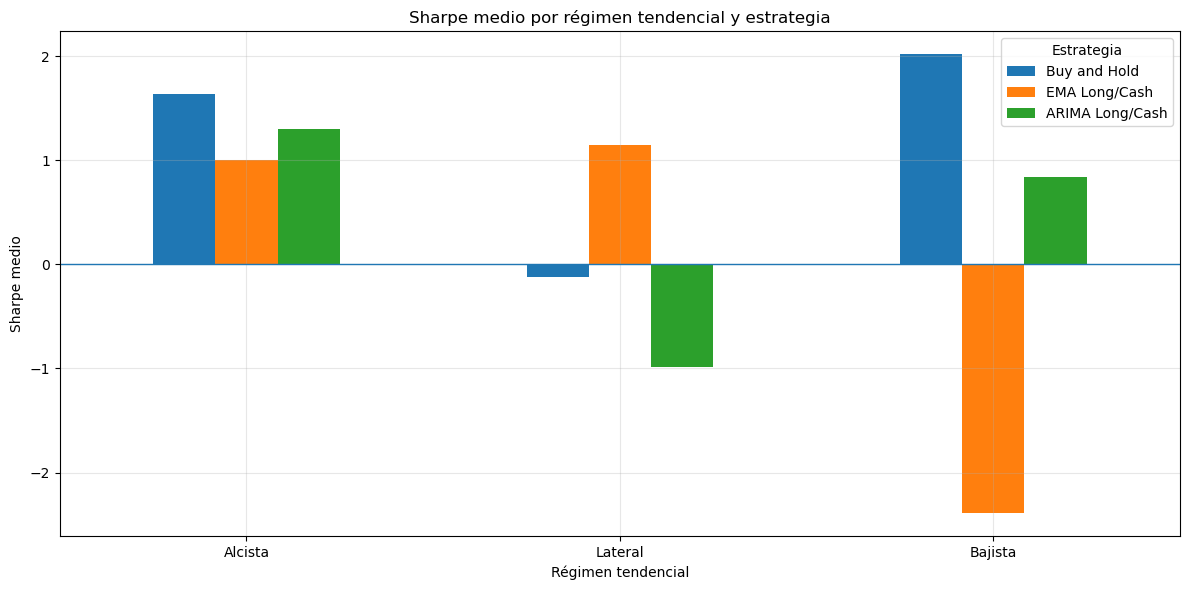

In [33]:
# ============================================================
# 7.7 GRÁFICO: SHARPE MEDIO POR RÉGIMEN TENDENCIAL
# ============================================================

ax = trend_sharpe_pivot.plot(
    kind="bar",
    figsize=(12, 6),
    rot=0
)

ax.set_title("Sharpe medio por régimen tendencial y estrategia")
ax.set_xlabel("Régimen tendencial")
ax.set_ylabel("Sharpe medio")
ax.axhline(0, linewidth=1)
ax.grid(True, alpha=0.3)
ax.legend(title="Estrategia")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "mean_sharpe_by_trend_regime_strategy.png",
    dpi=300
)
plt.show()

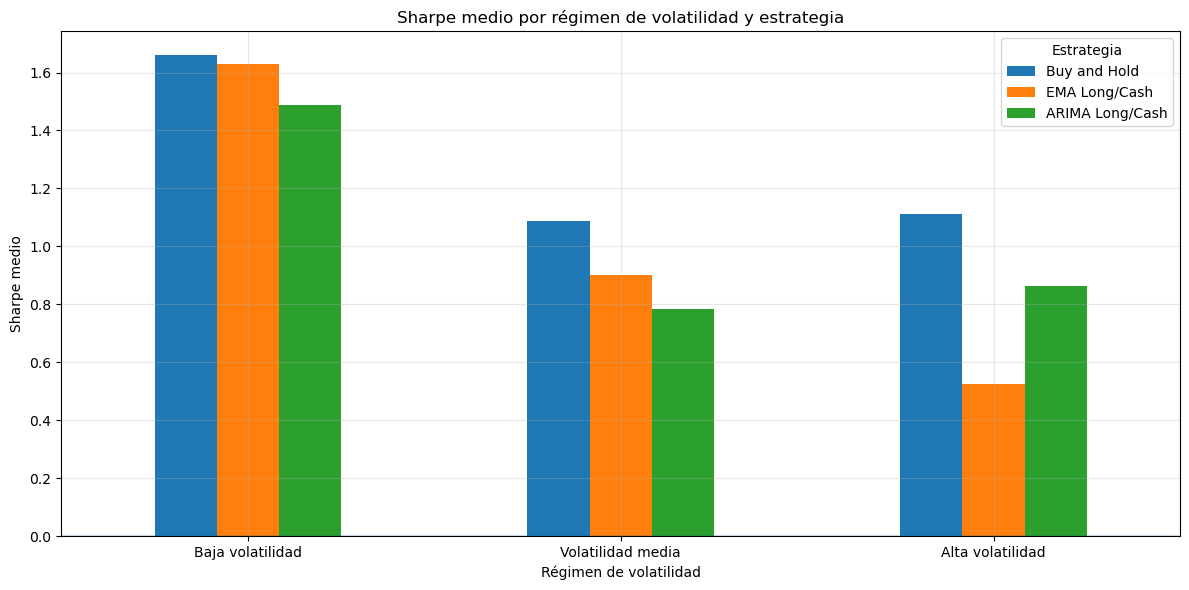

In [34]:
# ============================================================
# 7.8 GRÁFICO: SHARPE MEDIO POR RÉGIMEN DE VOLATILIDAD
# ============================================================

ax = volatility_sharpe_pivot.plot(
    kind="bar",
    figsize=(12, 6),
    rot=0
)

ax.set_title("Sharpe medio por régimen de volatilidad y estrategia")
ax.set_xlabel("Régimen de volatilidad")
ax.set_ylabel("Sharpe medio")
ax.axhline(0, linewidth=1)
ax.grid(True, alpha=0.3)
ax.legend(title="Estrategia")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "mean_sharpe_by_volatility_regime_strategy.png",
    dpi=300
)
plt.show()

## Análisis por régimen de mercado

El análisis por régimen permite observar que el comportamiento de las estrategias cambia de forma relevante según el contexto de mercado. Este resultado complementa la comparación global anterior, ya que muestra que una estrategia puede funcionar bien en términos agregados, pero comportarse de forma diferente en mercados alcistas, bajistas, laterales o con distintos niveles de volatilidad.

En los regímenes alcistas, buy and hold obtiene el mejor Sharpe medio y la mayor rentabilidad media. Este resultado es coherente con la lógica de la estrategia pasiva: cuando el mercado mantiene una tendencia positiva, permanecer invertido permite capturar completamente el movimiento alcista. Las estrategias activas, al introducir filtros de entrada y salida, pueden perder parte de la subida si retrasan la entrada o pasan temporalmente a liquidez.

En los regímenes laterales, la estrategia EMA Long/Cash optimizada obtiene el mejor comportamiento medio. Este resultado es especialmente relevante, ya que en mercados sin una dirección clara buy and hold puede quedar expuesto a oscilaciones sin capturar una tendencia definida. La estrategia basada en medias móviles, al reducir exposición cuando no identifica una estructura favorable, consigue mejorar el Sharpe medio y reducir el drawdown respecto al benchmark pasivo.

En los regímenes bajistas, los resultados deben interpretarse con cautela. Aunque buy and hold y ARIMA muestran un Sharpe medio positivo, algunos activos presentan pocas observaciones clasificadas como bajistas durante el periodo de prueba. Además, un régimen clasificado como bajista puede incluir rebotes temporales dentro de una estructura descendente. Por tanto, no debe concluirse que buy and hold sea necesariamente superior en mercados bajistas de forma general, sino que en los segmentos bajistas concretos identificados durante este periodo obtuvo buenos resultados medios. La estrategia EMA Long/Cash, en cambio, muestra un resultado negativo en este régimen, lo que indica que su señal pudo quedar mal posicionada en algunos cambios de tendencia o rebotes.

El análisis por volatilidad muestra que, en periodos de baja volatilidad, las tres estrategias obtienen resultados positivos, con una ligera ventaja de buy and hold en Sharpe medio. Esto sugiere que, cuando el mercado es más estable, permanecer invertido puede ser una alternativa eficiente.

En periodos de volatilidad media, buy and hold obtiene el mejor Sharpe medio, seguido de la estrategia EMA Long/Cash y de ARIMA Long/Cash. Este resultado indica que, incluso en entornos con más movimiento que los periodos de baja volatilidad, la estrategia pasiva sigue siendo muy competitiva en términos de rentabilidad ajustada por riesgo. No obstante, la estrategia EMA mantiene interés desde el punto de vista defensivo, ya que puede reducir el drawdown medio aunque no alcance el mejor Sharpe.

En alta volatilidad, buy and hold mantiene el mejor Sharpe medio, aunque con mayor drawdown medio que la estrategia EMA. Este resultado refuerza una conclusión ya observada en secciones anteriores: las estrategias activas no siempre maximizan la rentabilidad o el Sharpe, pero pueden actuar como mecanismos defensivos al reducir parte de las caídas.

En conjunto, el análisis por régimen confirma que no existe una estrategia universalmente superior. Buy and hold funciona especialmente bien en mercados alcistas y en varios contextos de volatilidad, mientras que la estrategia EMA aporta valor en escenarios laterales y como herramienta de reducción de drawdown. ARIMA presenta resultados competitivos en determinados activos y contextos, pero no domina de forma sistemática en el análisis por regímenes. Por tanto, la utilidad de cada estrategia depende del régimen de mercado y del objetivo principal del inversor: rentabilidad absoluta, control del riesgo o mejora de la rentabilidad ajustada por volatilidad.


# 8. Discusión: robustez, sobreajuste y limitaciones

Una vez comparadas las estrategias y analizado su comportamiento por régimen de mercado, es necesario interpretar los resultados desde una perspectiva crítica. En trading algorítmico, un buen resultado histórico no implica necesariamente que una estrategia vaya a funcionar en el futuro. Por ello, esta sección analiza la robustez de los resultados, el riesgo de sobreajuste y las principales limitaciones metodológicas del estudio.

## 8.1 Interpretación y robustez de los resultados

Los resultados muestran que ninguna estrategia domina de forma universal en todos los activos. Buy and Hold obtiene una rentabilidad muy competitiva y, en varios casos, también un ratio de Sharpe superior. Esto confirma que una estrategia pasiva puede ser difícil de superar, especialmente en activos con tendencias alcistas persistentes.

La estrategia EMA Long/Cash optimizada destaca principalmente por su capacidad para reducir el máximo drawdown en determinados activos. Aunque no siempre maximiza la rentabilidad, puede interpretarse como una estrategia defensiva orientada al control del riesgo, ya que reduce la exposición en algunos tramos adversos del mercado.

La estrategia ARIMA Long/Cash presenta un comportamiento más irregular. No mejora de forma generalizada a Buy and Hold, aunque obtiene resultados competitivos en algunos activos concretos. Esto sugiere que los modelos de series temporales pueden aportar valor en ciertos contextos, pero su capacidad predictiva no se mantiene de forma homogénea en todos los mercados analizados.

En conjunto, los resultados apoyan una conclusión prudente: las estrategias activas pueden ser útiles en determinados activos o regímenes, pero no sustituyen de forma sistemática a una estrategia pasiva. La robustez debe evaluarse considerando varias métricas, distintos activos y el comportamiento fuera de muestra.

## 8.2 Riesgo de sobreajuste

Uno de los principales riesgos en el diseño de estrategias de trading es el sobreajuste. Este problema aparece cuando una estrategia se adapta demasiado bien a los datos históricos utilizados para construirla, pero pierde capacidad de generalización al aplicarse a datos nuevos.

En este proyecto se han tomado varias decisiones para reducir este riesgo. La estrategia EMA no se ha optimizado sobre todo el periodo disponible, sino únicamente sobre el periodo de entrenamiento. Posteriormente, los parámetros seleccionados se han evaluado en un periodo de prueba no utilizado durante la optimización.

Además, la optimización se ha realizado buscando un comportamiento medio en el conjunto de activos, no maximizando el resultado de un único activo. Esto reduce el riesgo de construir una estrategia excesivamente adaptada a Bitcoin, Apple u otro activo concreto. También se ha empleado un grid de parámetros limitado y razonable desde un punto de vista financiero, evitando una búsqueda excesivamente amplia que pudiera aumentar la probabilidad de encontrar buenos resultados por azar.

Aun así, el riesgo de sobreajuste no desaparece completamente. La elección de activos, el periodo analizado, las ventanas utilizadas y las métricas seleccionadas pueden influir en las conclusiones. Por tanto, los resultados deben interpretarse como una evaluación exploratoria y no como una validación definitiva de una estrategia de inversión.

## 8.3 Limitaciones de datos y backtesting

El análisis utiliza datos históricos descargados mediante `yfinance`. Esta fuente es suficiente para un proyecto académico, pero presenta limitaciones frente a bases de datos profesionales. Los datos pueden estar sujetos a ajustes, diferencias de calendario, huecos de cotización y posibles discrepancias entre proveedores.

Además, los activos analizados no cotizan bajo las mismas condiciones. Bitcoin cotiza de forma continua, mientras que ETFs y acciones estadounidenses cotizan solo durante sesiones de mercado. EUR/USD también tiene una estructura de negociación distinta. Para mantener una comparación homogénea se utilizan datos diarios, aunque esta decisión simplifica diferencias reales entre mercados.

La volatilidad anualizada de Bitcoin quedaría subestimada en un factor aproximado de $\sqrt{365/252} \approx 1{,}20$ respecto a una anualización con 365 días, lo que también infla ligeramente su ratio de Sharpe.

El ratio de Sharpe se calcula asumiendo una tasa libre de riesgo $r_f = 0$. Esta simplificación es habitual en análisis académicos exploratorios, pero debe tenerse en cuenta que durante el periodo de prueba (2023–2026) la tasa libre de riesgo en EE.UU. se situó entre el 4,25 % y el 5,50 % anual. Los valores de Sharpe aquí reportados son superiores a los que se obtendrían descontando dicha tasa, aunque las conclusiones comparativas relativas entre estrategias no cambian cualitativamente.

El backtesting realizado también es una aproximación simplificada. Aunque se incorporan costes de transacción aproximados, no se modelan con detalle otros elementos como slippage, horquillas bid-ask, comisiones variables, liquidez, impuestos, costes de financiación o impacto de mercado. Estos factores podrían reducir la rentabilidad obtenida en una operativa real.

Por último, las estrategias se evalúan en modo Long/Cash, sin posiciones cortas ni apalancamiento. Esta decisión permite una comparación más sencilla y homogénea, pero también limita el alcance del análisis.

## 8.4 Limitaciones específicas de EMA y ARIMA

La estrategia EMA Long/Cash se basa en seguimiento de tendencia. Este tipo de estrategia puede funcionar bien cuando existen movimientos direccionales persistentes, pero suele tener dificultades en mercados laterales o con cambios frecuentes de dirección.

Una limitación importante es que el cruce de medias móviles genera señales con retraso. La estrategia puede entrar tarde en movimientos alcistas y salir después de que parte de la caída ya se haya producido. Por ello, aunque puede reducir drawdown en algunos activos, también puede sacrificar rentabilidad cuando el mercado recupera rápidamente.

La estrategia ARIMA, por su parte, intenta predecir retornos futuros a partir de retornos pasados. Sin embargo, los retornos financieros presentan una elevada componente aleatoria, lo que dificulta la predicción a corto plazo. Además, ARIMA es un modelo lineal y puede tener problemas para capturar relaciones no lineales, cambios bruscos de régimen, eventos externos o comportamientos extremos.

Por tanto, ARIMA debe interpretarse como una aproximación estadística básica de series temporales, no como un modelo predictivo avanzado capaz de anticipar de forma consistente los movimientos del mercado.

## 8.5 Mejoras futuras y síntesis final

Como posibles líneas de mejora, se podrían ampliar los activos analizados, utilizar validaciones walk-forward más completas, incorporar variables adicionales como volumen o indicadores macroeconómicos, probar modelos predictivos alternativos y modelar de forma más realista los costes de ejecución.

También sería interesante estudiar estrategias Long/Short, incorporar gestión dinámica del tamaño de posición y evaluar el comportamiento en periodos fuera de muestra más recientes. No obstante, estas extensiones requerirían supuestos adicionales y aumentarían la complejidad del análisis.

Una extensión práctica del proyecto es la implementación de la lógica en TradingView mediante Pine Script. Esta versión permite visualizar señales de entrada y salida sobre gráficos reales, así como explorar reglas de exposición dinámica. Sin embargo, se trata como un anexo práctico separado del análisis principal, ya que el uso de apalancamiento o exposición variable introduce riesgos adicionales.

En síntesis, el proyecto muestra que el diseño de estrategias de trading requiere una evaluación cuidadosa. La comparación entre Buy and Hold, EMA Long/Cash y ARIMA Long/Cash evidencia que la simplicidad de una estrategia pasiva puede ser difícil de superar. No obstante, las estrategias activas pueden aportar valor cuando el objetivo no es únicamente maximizar rentabilidad, sino también reducir drawdown o mejorar el control del riesgo.

El resultado más relevante del trabajo no es encontrar una estrategia ganadora universal, sino construir un marco de análisis capaz de comparar estrategias, identificar sus fortalezas y limitaciones, y evaluar su comportamiento bajo distintos contextos de mercado.


## 9. Conclusiones finales

Este trabajo ha comparado tres estrategias sistemáticas —Buy and Hold, EMA Long/Cash 
y ARIMA Long/Cash— sobre siete activos financieros en el periodo de prueba 
(2023–2026). Las conclusiones principales son:

**1. Buy and Hold sigue siendo muy difícil de superar en rentabilidad.** Obtiene 
la mayor rentabilidad total en seis de los siete activos. En mercados con tendencia 
alcista persistente (SPY, QQQ, Apple), permanecer invertido captura completamente 
el movimiento sin costes de transacción ni riesgo de quedarse fuera.

**2. La estrategia EMA Long/Cash aporta valor como herramienta de control del 
riesgo.** No maximiza la rentabilidad ni el Sharpe, pero reduce el máximo drawdown 
en cuatro activos (Bitcoin, QQQ, Apple, EUR/USD). Su mejor resultado relativo 
aparece en mercados laterales, confirmado por el análisis por régimen.

**3. La estrategia ARIMA Long/Cash, con órdenes seleccionados por AutoARIMA, 
obtiene el mejor ratio de Sharpe en tres activos: Bitcoin, SPY y Procter & Gamble.** 
En Bitcoin y PG mejora también el drawdown. Su peor resultado se observa en EUR/USD, 
donde el modelo no logra capturar estructura predictiva útil.

**4. El análisis por régimen confirma la dependencia contextual.** Buy and Hold es 
superior en mercados alcistas. EMA aporta valor en mercados laterales. Ninguna 
estrategia domina en todos los regímenes.

**5. El indicador de TradingView** ilustra cómo trasladar el análisis cuantitativo 
a una herramienta visual de apoyo. Resulta útil en Bitcoin (activo tendencial y 
volátil), no supera a Buy and Hold en SPY, y falla en Procter & Gamble por su 
comportamiento menos tendencial.

**Conclusión principal**: La complejidad de una estrategia activa debe justificarse 
no solo por rentabilidad, sino por su control del riesgo y consistencia fuera de 
muestra. En este análisis, ninguna estrategia activa supera sistemáticamente a Buy 
and Hold, pero cada una aporta valor en contextos específicos.

*Los resultados de este trabajo no constituyen una recomendación de inversión y 
responden a fines exclusivamente académicos.*

# Anexo 1. 

## Evaluación práctica del indicador en TradingView

Tras comparar en Python las estrategias Buy and Hold, EMA Long/Cash y ARIMA Long/Cash, este anexo evalúa una implementación práctica en TradingView. La pregunta de fondo es la misma que guía el trabajo principal: **¿compensa aplicar una estrategia activa de compra y venta, o resulta más eficiente mantener una posición pasiva mediante Buy and Hold?**

Para ello se analiza un indicador técnico aplicado a tres casos representativos:

* **BTC 4H**: activo volátil y tendencial, útil para estudiar entradas, salidas y control del riesgo en una temporalidad más operativa.
* **SPY 1D**: benchmark de mercado amplio, donde Buy and Hold suele ser difícil de superar.
* **PG 1D**: activo más defensivo y menos direccional, útil para comprobar las limitaciones del indicador técnico.

El indicador combina filtros de tendencia, momentum, fuerza de mercado y control del riesgo mediante EMA rápida, EMA lenta, EMA macro, RSI, ADX y ATR. Las entradas se clasifican como **entrada fuerte**, **entrada moderada** o **entrada contra régimen**, según la alineación entre la señal técnica y el régimen macro. Las salidas pueden producirse por **stop ATR**, **trailing ATR**, **cruce de medias** o **pérdida de RSI**.

El objetivo del anexo no es repetir todo el backtesting principal, sino comprobar de forma aplicada si una estrategia basada en estas señales habría aportado una mejora clara frente a Buy and Hold. Para ello se comparan la rentabilidad obtenida, el número de operaciones, el tipo de entradas y los mecanismos de salida activados.

## Parámetros utilizados

El indicador permite modificar sus parámetros para adaptarse al activo y a la temporalidad analizada. En este anexo se utilizan configuraciones razonables y coherentes con el análisis previo, evitando ajustar manualmente los valores hasta obtener señales favorables en el pasado.

| Activo | Temporalidad | EMA rápida | EMA lenta | EMA macro | RSI entrada | RSI salida | ADX mínimo | Distancia máxima EMA rápida | Interpretación                                                           |
| ------ | -----------: | ---------: | --------: | --------: | ----------: | ---------: | ---------: | --------------------------: | ------------------------------------------------------------------------ |
| BTC    |           4H |         20 |        50 |      1000 |          55 |         45 |         22 |                        3.5% | Configuración swing para activo continuo y volátil                       |
| SPY    |           1D |          5 |       100 |       200 |          50 |         45 |         18 |                        5.0% | Configuración defensiva próxima al análisis diario                       |
| PG     |           1D |          5 |       100 |       200 |          50 |         45 |         15 |                        4.0% | Uso exploratorio; la mejora principal en Python vino de ARIMA, no de EMA |

En BTC se utiliza temporalidad de 4 horas porque el activo cotiza de forma continua y permite observar señales swing con mayor detalle. La EMA1000 en 4H actúa como filtro de contexto macro de largo plazo. En SPY y PG se utiliza temporalidad diaria para mantener mayor coherencia con el análisis cuantitativo realizado en Python.

## Criterio de simulación

Para comparar el indicador frente a Buy and Hold, las señales se traducen en distintos niveles de exposición sobre una cartera inicial de **10.000 dólares**. No se utiliza apalancamiento: la estrategia solo decide qué porcentaje de la cartera queda invertido en cada operación.

| Tipo de señal          | Exposición aplicada |
| ---------------------- | ------------------: |
| Entrada fuerte         |  100% de la cartera |
| Entrada moderada       |   50% de la cartera |
| Entrada contra régimen |   25% de la cartera |
| Sin señal o salida     |    0% de la cartera |

Las entradas no tienen comisión. Cada salida aplica una comisión del **0,1%** sobre el valor vendido. La parte no invertida permanece en liquidez.

Con este planteamiento, la comparación frente a Buy and Hold es más prudente que una versión apalancada. La estrategia activa solo se considera útil si la gestión dinámica de exposición compensa la mayor complejidad operativa de entrar y salir del mercado.

In [35]:
# ============================================================
# CARGA DEL INDICADOR EXTERNO DE TRADINGVIEW
# ============================================================

from pathlib import Path

PROJECT_DIR = Path(r"D:\Master en Business Analytics\enfoque funcional y sectorial\Trabajo Final")
TRADINGVIEW_SCRIPT_PATH = PROJECT_DIR / "scripts" / "indicador_trading_view.txt"

if TRADINGVIEW_SCRIPT_PATH.exists():
    pine_script = TRADINGVIEW_SCRIPT_PATH.read_text(encoding="utf-8")
    script_lines = pine_script.splitlines()

    print("Indicador TradingView cargado correctamente.")
    print(f"Archivo: {TRADINGVIEW_SCRIPT_PATH}")
    print(f"Número de líneas: {len(script_lines)}")
    print(f"Primera línea: {script_lines[0]}")
else:
    print(f"Script no encontrado: {TRADINGVIEW_SCRIPT_PATH}")
    print("Archivos disponibles en la carpeta scripts:")

    scripts_dir = PROJECT_DIR / "scripts"
    if scripts_dir.exists():
        for p in scripts_dir.iterdir():
            print("-", p.name)
    else:
        print("La carpeta scripts tampoco existe.")

Indicador TradingView cargado correctamente.
Archivo: D:\Master en Business Analytics\enfoque funcional y sectorial\Trabajo Final\scripts\indicador_trading_view.txt
Número de líneas: 305
Primera línea: //@version=6


### BTC 4H - Evaluación práctica del indicador

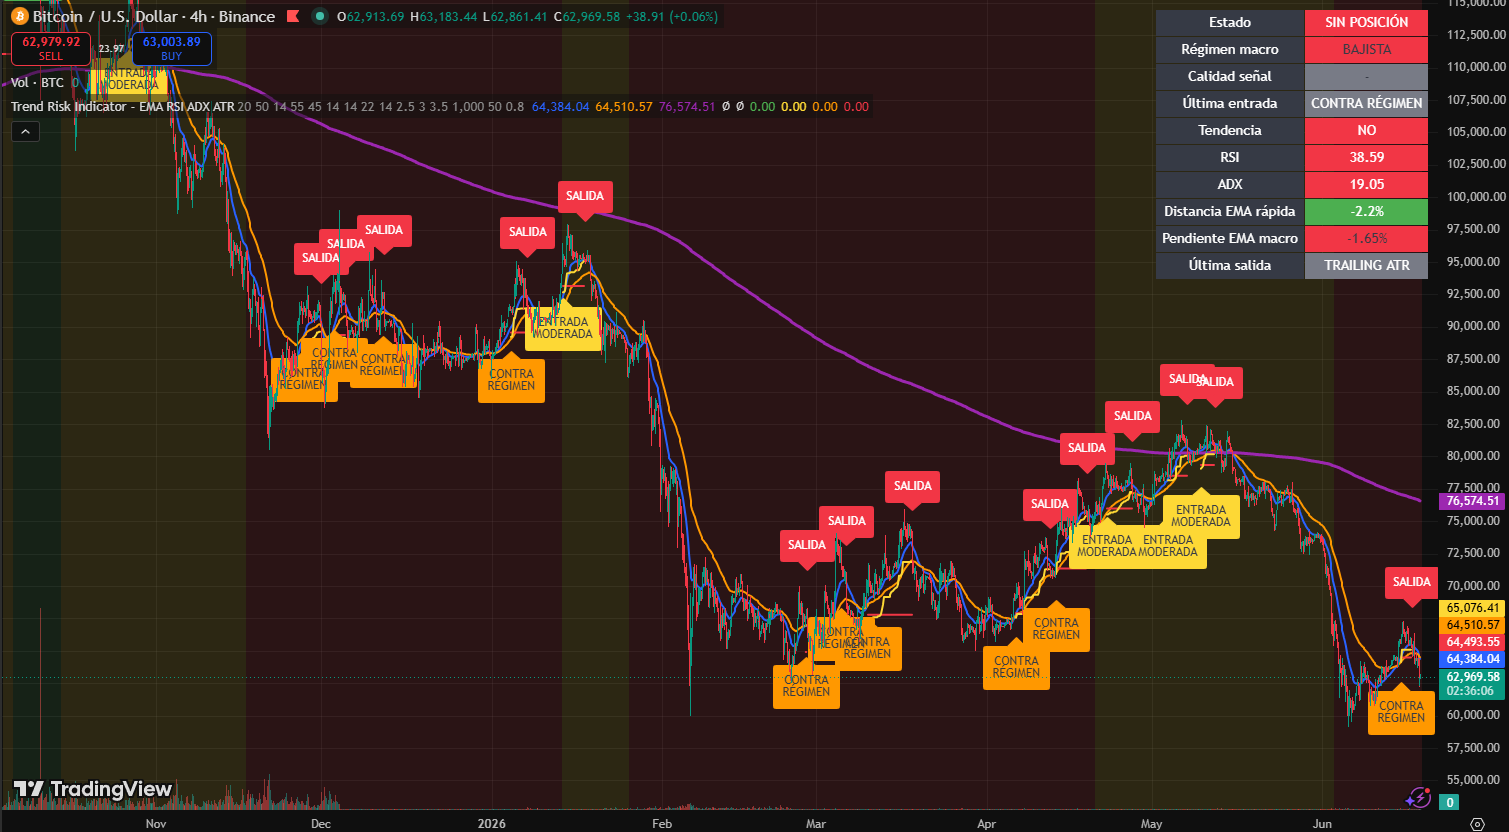

### SPY 1D - Evaluación práctica del indicador

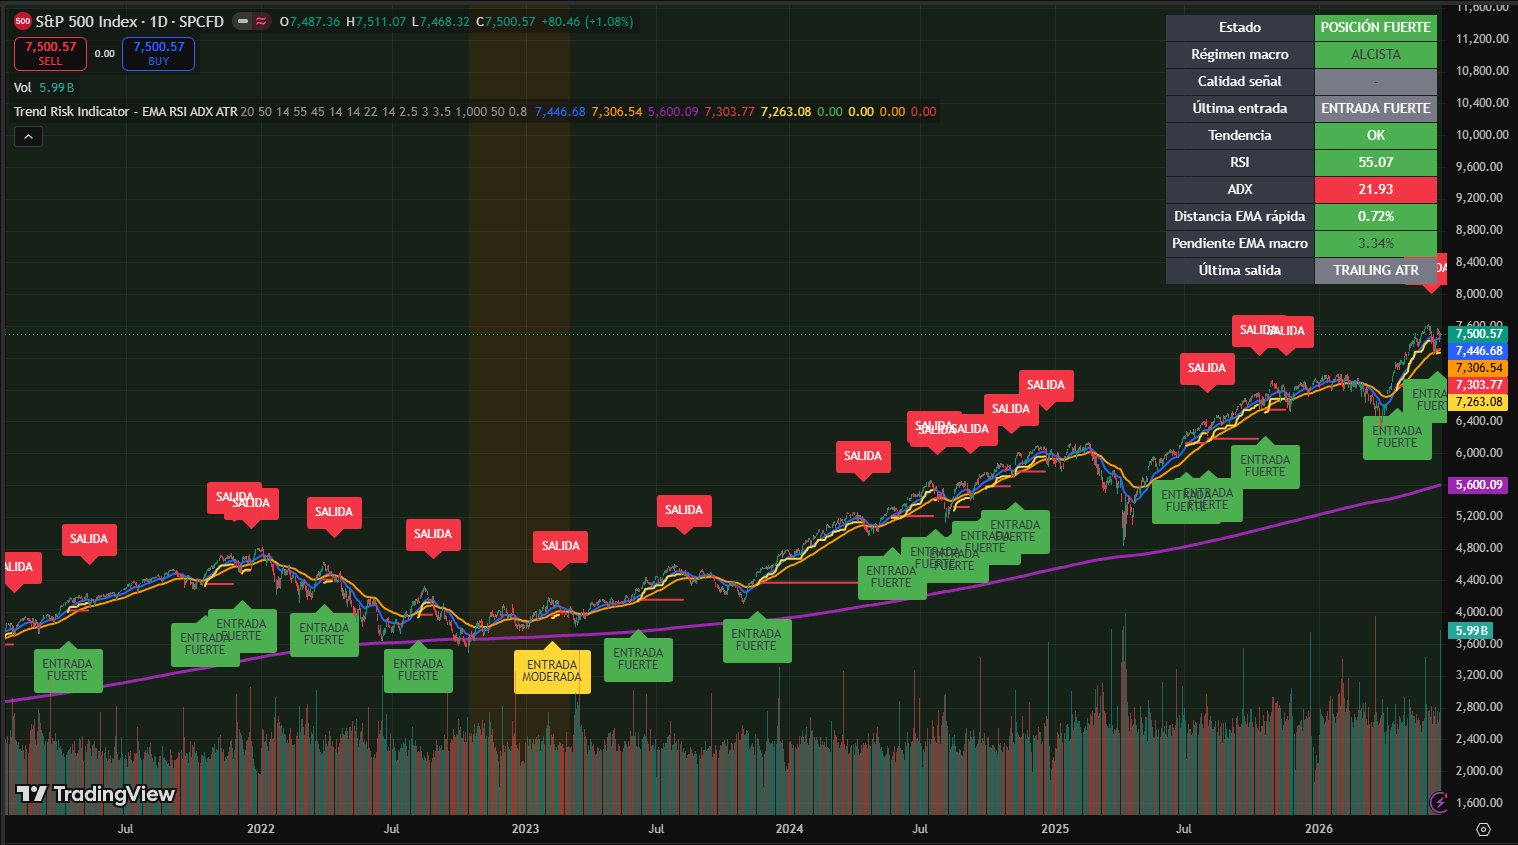

### PG 1D - Evaluación práctica del indicador

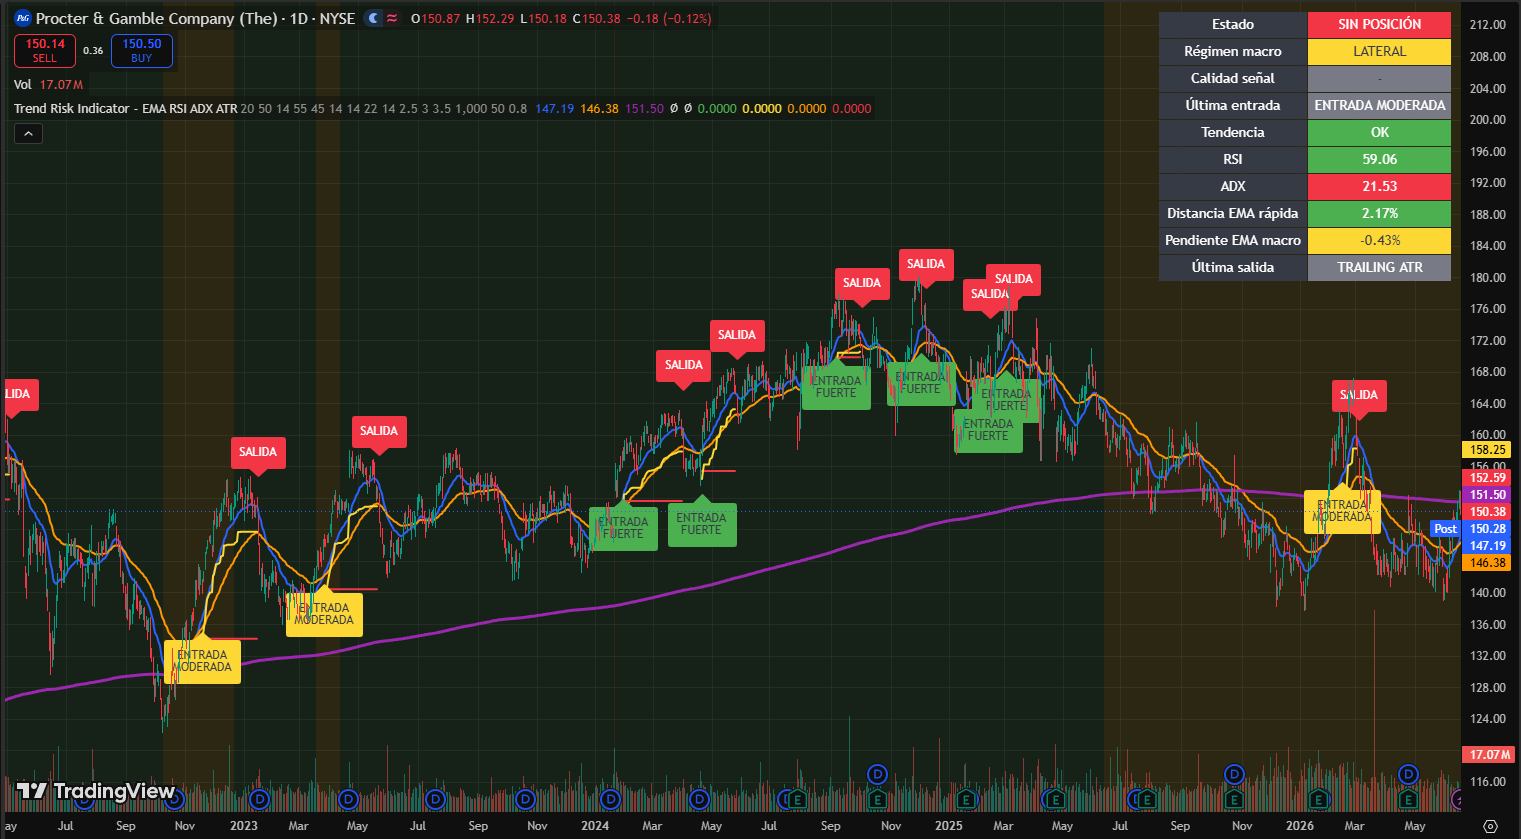

In [36]:
# ============================================================
# CARGA DE CAPTURAS DE TRADINGVIEW
# ============================================================

from IPython.display import Image, display, Markdown
from pathlib import Path

# Ruta real donde están las capturas
TRADINGVIEW_DIR = Path(
    r"D:\Master en Business Analytics\enfoque funcional y sectorial\Trabajo Final\images\tradingview"
)

tradingview_images = {
    "BTC 4H - Evaluación práctica del indicador": "tradingview_btc_4h.png",
    "SPY 1D - Evaluación práctica del indicador": "tradingview_spy_1d.png",
    "PG 1D - Evaluación práctica del indicador": "tradingview_pg_1d.png"
}

for title, image_name in tradingview_images.items():
    image_path = TRADINGVIEW_DIR / image_name

    display(Markdown(f"### {title}"))

    if image_path.exists():
        display(Image(filename=str(image_path)))
    else:
        display(Markdown(f"*Captura pendiente de incorporar: `{image_name}`*"))

In [37]:
# ============================================================
# ANEXO 1.3 BACKTEST PRÁCTICO DEL INDICADOR DE TRADINGVIEW
# ============================================================

import yfinance as yf

TRADINGVIEW_INITIAL_CAPITAL = 10_000
TRADINGVIEW_EXIT_COMMISSION = 0.001  # 0,1% aplicado solo en salidas

TRADINGVIEW_START_DATE = TEST_START_DATE
TRADINGVIEW_END_DATE = None  # usa None para descargar hasta el último dato disponible

EXPOSURE_BY_ENTRY_TYPE = {
    "ENTRADA FUERTE": 1.00,
    "ENTRADA MODERADA": 0.50,
    "CONTRA RÉGIMEN": 0.25
}

tradingview_cases = {
"BTC 4H": {
    "ticker": "BTC-USD",
    "download_interval": "1h",
    "resample_rule": "4h",
    "start_date_override": (pd.Timestamp.today() - pd.Timedelta(days=729)).strftime("%Y-%m-%d"),
    "fast_ema": 20,
    "slow_ema": 50,
    "macro_ema": 1000,
    "rsi_entry": 55,
    "rsi_exit": 45,
    "adx_min": 22,
    "max_distance_from_ema": 0.035
},
    "SPY 1D": {
        "ticker": "SPY",
        "download_interval": "1d",
        "resample_rule": None,
        "start_date_override": None,
        "fast_ema": 5,
        "slow_ema": 100,
        "macro_ema": 200,
        "rsi_entry": 50,
        "rsi_exit": 45,
        "adx_min": 18,
        "max_distance_from_ema": 0.050
    },
    "PG 1D": {
        "ticker": "PG",
        "download_interval": "1d",
        "resample_rule": None,
        "start_date_override": None,
        "fast_ema": 5,
        "slow_ema": 100,
        "macro_ema": 200,
        "rsi_entry": 50,
        "rsi_exit": 45,
        "adx_min": 15,
        "max_distance_from_ema": 0.040
    }
}


def download_case_ohlc(ticker, interval, start_date, end_date=None, resample_rule=None):
    """
    Descarga OHLC. Para BTC 4H descarga 1H y reagrupa a 4h.
    """
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval=interval,
        auto_adjust=False,
        progress=False
    )

    if data.empty:
        raise ValueError(
            f"No se han descargado datos para {ticker} con intervalo {interval} "
            f"desde {start_date}. Para datos intradía, yfinance limita el histórico disponible."
        )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.rename(columns=str.lower)

    required_cols = ["open", "high", "low", "close"]
    data = data[required_cols].dropna()

    if resample_rule is not None:
        data = data.resample(resample_rule).agg({
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last"
        }).dropna()

    return data


def rma(series, length):
    """
    Media móvil suavizada tipo Wilder, usada en RSI, ATR y ADX.
    """
    return series.ewm(alpha=1 / length, adjust=False).mean()


def calculate_rsi(close, length=14):
    delta = close.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = rma(gains, length)
    avg_loss = rma(losses, length)

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


def calculate_atr(high, low, close, length=14):
    previous_close = close.shift(1)

    tr = pd.concat(
        [
            high - low,
            (high - previous_close).abs(),
            (low - previous_close).abs()
        ],
        axis=1
    ).max(axis=1)

    return rma(tr, length)


def calculate_adx(high, low, close, adx_len=14, adx_smooth=14):
    up_move = high.diff()
    down_move = -low.diff()

    plus_dm = np.where(
        (up_move > down_move) & (up_move > 0),
        up_move,
        0.0
    )

    minus_dm = np.where(
        (down_move > up_move) & (down_move > 0),
        down_move,
        0.0
    )

    plus_dm = pd.Series(plus_dm, index=high.index)
    minus_dm = pd.Series(minus_dm, index=high.index)

    atr = calculate_atr(high, low, close, adx_len)

    plus_di = 100 * rma(plus_dm, adx_len) / atr
    minus_di = 100 * rma(minus_dm, adx_len) / atr

    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx = rma(dx, adx_smooth)

    return adx


def calculate_max_drawdown(equity_curve):
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    return drawdown.min()


def run_tradingview_indicator_backtest(
    ohlc,
    case_name,
    ticker,
    fast_ema,
    slow_ema,
    macro_ema,
    rsi_entry,
    rsi_exit,
    adx_min,
    max_distance_from_ema,
    initial_capital=10_000,
    exit_commission=0.001,
    exposure_by_entry_type=None,
    rsi_len=14,
    adx_len=14,
    adx_smooth=14,
    atr_len=14,
    atr_stop_mult=2.5,
    atr_trail_mult=3.0,
    macro_slope_lookback=50,
    macro_slope_threshold=0.008
):
    """
    Reconstruye en Python la lógica práctica del indicador:
    entrada por tendencia + RSI + ADX + distancia a EMA,
    clasificación por régimen macro y salida por ATR, trailing ATR,
    cruce EMA o pérdida RSI.
    """

    if exposure_by_entry_type is None:
        exposure_by_entry_type = {
            "ENTRADA FUERTE": 1.00,
            "ENTRADA MODERADA": 0.50,
            "CONTRA RÉGIMEN": 0.25
        }

    data = ohlc.copy()

    close = data["close"]
    high = data["high"]
    low = data["low"]

    data["ema_fast"] = close.ewm(span=fast_ema, adjust=False).mean()
    data["ema_slow"] = close.ewm(span=slow_ema, adjust=False).mean()
    data["ema_slow_slope"] = data["ema_slow"] - data["ema_slow"].shift(5)

    data["rsi"] = calculate_rsi(close, rsi_len)
    data["adx"] = calculate_adx(high, low, close, adx_len, adx_smooth)
    data["atr"] = calculate_atr(high, low, close, atr_len)

    data["macro_ema"] = close.ewm(span=macro_ema, adjust=False).mean()
    data["macro_slope_pct"] = (
        data["macro_ema"] / data["macro_ema"].shift(macro_slope_lookback)
    ) - 1

    data["macro_bull"] = data["macro_slope_pct"] > macro_slope_threshold
    data["macro_bear"] = data["macro_slope_pct"] < -macro_slope_threshold
    data["macro_sideways"] = ~(data["macro_bull"] | data["macro_bear"])

    data["price_extension"] = close / data["ema_fast"] - 1

    data["trend_ok"] = (
        (data["ema_fast"] > data["ema_slow"]) &
        (data["ema_slow_slope"] > 0)
    )

    data["momentum_ok"] = data["rsi"] > rsi_entry
    data["adx_ok"] = data["adx"] > adx_min
    data["not_extended"] = data["price_extension"] < max_distance_from_ema

    data["entry_signal"] = (
        data["trend_ok"] &
        data["momentum_ok"] &
        data["adx_ok"] &
        data["not_extended"]
    )

    capital = initial_capital
    cash = initial_capital
    units = 0.0

    in_position = False
    entry_price = np.nan
    highest_price = np.nan
    initial_stop = np.nan
    trailing_stop = np.nan
    current_entry_type = None
    current_exposure = 0.0

    equity_records = []
    trade_records = []

    for current_date, row in data.iterrows():
        current_close = row["close"]

        if np.isnan(current_close):
            continue

        exit_signal = False
        exit_reason = None

        if in_position:
            highest_price = max(highest_price, current_close)
            trailing_stop = max(
                trailing_stop,
                highest_price - atr_trail_mult * row["atr"]
            )

            atr_stop_hit = current_close <= initial_stop
            trailing_stop_hit = current_close <= trailing_stop
            ema_exit = row["ema_fast"] < row["ema_slow"]
            rsi_exit_hit = row["rsi"] < rsi_exit

            if atr_stop_hit or trailing_stop_hit or ema_exit or rsi_exit_hit:
                exit_signal = True

                if atr_stop_hit:
                    exit_reason = "STOP ATR"
                elif trailing_stop_hit:
                    exit_reason = "TRAILING ATR"
                elif ema_exit:
                    exit_reason = "CRUCE EMA"
                else:
                    exit_reason = "PÉRDIDA RSI"

                gross_exit_value = units * current_close
                exit_cost = gross_exit_value * exit_commission
                net_exit_value = gross_exit_value - exit_cost

                cash = cash + net_exit_value
                capital_after = cash

                trade_records[-1].update({
                    "exit_date": current_date,
                    "exit_price": current_close,
                    "exit_reason": exit_reason,
                    "gross_exit_value": gross_exit_value,
                    "exit_cost": exit_cost,
                    "capital_after": capital_after,
                    "trade_return_asset": (current_close / entry_price) - 1,
                    "trade_return_portfolio": (
                        capital_after / trade_records[-1]["capital_before"]
                    ) - 1
                })

                units = 0.0
                in_position = False
                entry_price = np.nan
                highest_price = np.nan
                initial_stop = np.nan
                trailing_stop = np.nan
                current_entry_type = None
                current_exposure = 0.0
                capital = capital_after

        if not in_position and row["entry_signal"]:
            if row["macro_bull"]:
                entry_type = "ENTRADA FUERTE"
            elif row["macro_sideways"]:
                entry_type = "ENTRADA MODERADA"
            else:
                entry_type = "CONTRA RÉGIMEN"

            exposure = exposure_by_entry_type[entry_type]

            capital_before = cash
            invested_capital = capital_before * exposure
            remaining_cash = capital_before - invested_capital

            units = invested_capital / current_close
            cash = remaining_cash

            in_position = True
            entry_price = current_close
            highest_price = current_close
            initial_stop = current_close - atr_stop_mult * row["atr"]
            trailing_stop = current_close - atr_trail_mult * row["atr"]

            current_entry_type = entry_type
            current_exposure = exposure

            trade_records.append({
                "case_name": case_name,
                "ticker": ticker,
                "entry_date": current_date,
                "entry_price": current_close,
                "entry_type": entry_type,
                "exposure": exposure,
                "capital_before": capital_before,
                "invested_capital": invested_capital,
                "cash_after_entry": remaining_cash
            })

        current_equity = cash + units * current_close

        equity_records.append({
            "date": current_date,
            "case_name": case_name,
            "ticker": ticker,
            "equity": current_equity,
            "cash": cash,
            "position_value": units * current_close,
            "in_position": in_position,
            "entry_type": current_entry_type
        })

    equity_df = pd.DataFrame(equity_records).set_index("date")
    trades_df = pd.DataFrame(trade_records)

    # Si queda una operación abierta al final, se valora a mercado, pero no se cuenta como salida cerrada.
    final_capital = equity_df["equity"].iloc[-1]
    total_return = final_capital / initial_capital - 1
    max_drawdown = calculate_max_drawdown(equity_df["equity"])

    if trades_df.empty:
        summary = {
            "case_name": case_name,
            "ticker": ticker,
            "initial_capital": initial_capital,
            "final_capital_indicator": final_capital,
            "indicator_total_return": total_return,
            "indicator_max_drawdown": max_drawdown,
            "strong_entries": 0,
            "moderate_entries": 0,
            "against_regime_entries": 0,
            "atr_stop_exits": 0,
            "trailing_atr_exits": 0,
            "ema_cross_exits": 0,
            "rsi_loss_exits": 0,
            "total_entries": 0,
            "total_exits": 0,
            "total_exit_cost": 0.0
        }
    else:
        closed_trades = trades_df.dropna(subset=["exit_date"]).copy()

        summary = {
            "case_name": case_name,
            "ticker": ticker,
            "initial_capital": initial_capital,
            "final_capital_indicator": final_capital,
            "indicator_total_return": total_return,
            "indicator_max_drawdown": max_drawdown,
            "strong_entries": int((trades_df["entry_type"] == "ENTRADA FUERTE").sum()),
            "moderate_entries": int((trades_df["entry_type"] == "ENTRADA MODERADA").sum()),
            "against_regime_entries": int((trades_df["entry_type"] == "CONTRA RÉGIMEN").sum()),
            "atr_stop_exits": int((closed_trades["exit_reason"] == "STOP ATR").sum()),
            "trailing_atr_exits": int((closed_trades["exit_reason"] == "TRAILING ATR").sum()),
            "ema_cross_exits": int((closed_trades["exit_reason"] == "CRUCE EMA").sum()),
            "rsi_loss_exits": int((closed_trades["exit_reason"] == "PÉRDIDA RSI").sum()),
            "total_entries": len(trades_df),
            "total_exits": len(closed_trades),
            "total_exit_cost": closed_trades["exit_cost"].sum() if "exit_cost" in closed_trades else 0.0
        }

    return data, equity_df, trades_df, summary


tradingview_ohlc_data = {}
tradingview_indicator_data = {}
tradingview_equity_curves = {}
tradingview_trade_logs = {}
tradingview_summaries = []

for case_name, config in tradingview_cases.items():
    ticker = config["ticker"]

    case_start_date = (
        config["start_date_override"]
        if config.get("start_date_override") is not None
        else TRADINGVIEW_START_DATE
    )

    ohlc = download_case_ohlc(
        ticker=ticker,
        interval=config["download_interval"],
        start_date=case_start_date,
        end_date=TRADINGVIEW_END_DATE,
        resample_rule=config["resample_rule"]
    )

    indicator_data, equity_df, trades_df, summary = run_tradingview_indicator_backtest(
        ohlc=ohlc,
        case_name=case_name,
        ticker=ticker,
        fast_ema=config["fast_ema"],
        slow_ema=config["slow_ema"],
        macro_ema=config["macro_ema"],
        rsi_entry=config["rsi_entry"],
        rsi_exit=config["rsi_exit"],
        adx_min=config["adx_min"],
        max_distance_from_ema=config["max_distance_from_ema"],
        initial_capital=TRADINGVIEW_INITIAL_CAPITAL,
        exit_commission=TRADINGVIEW_EXIT_COMMISSION,
        exposure_by_entry_type=EXPOSURE_BY_ENTRY_TYPE
    )

    tradingview_ohlc_data[case_name] = ohlc
    tradingview_indicator_data[case_name] = indicator_data
    tradingview_equity_curves[case_name] = equity_df
    tradingview_trade_logs[case_name] = trades_df

    tradingview_summaries.append(summary)

tradingview_backtest_summary = pd.DataFrame(tradingview_summaries)

tradingview_backtest_summary.to_csv(
    TABLES_DIR / "tradingview_indicator_backtest_summary.csv",
    index=False
)

tradingview_backtest_display = tradingview_backtest_summary.copy()

cols_to_round = [
    "initial_capital",
    "final_capital_indicator",
    "indicator_total_return",
    "indicator_max_drawdown",
    "total_exit_cost"
]

tradingview_backtest_display[cols_to_round] = (
    tradingview_backtest_display[cols_to_round].round(4)
)

display(tradingview_backtest_display)

,case_name,ticker,initial_capital,final_capital_indicator,indicator_total_return,indicator_max_drawdown,strong_entries,moderate_entries,against_regime_entries,atr_stop_exits,trailing_atr_exits,ema_cross_exits,rsi_loss_exits,total_entries,total_exits,total_exit_cost
0,BTC 4H,BTC-USD,10000,13264.6587,0.3265,-0.1063,18,17,10,4,27,2,12,45,45,362.6115
1,SPY 1D,SPY,10000,13747.4716,0.3747,-0.0889,20,2,1,2,12,1,7,23,22,245.8204
2,PG 1D,PG,10000,9513.5682,-0.0486,-0.1148,6,7,4,0,8,3,5,17,16,101.8529


In [38]:
# ============================================================
# COMPARACIÓN DEL INDICADOR FRENTE A BUY AND HOLD
# ============================================================

def calculate_buy_hold_from_ohlc(
    ohlc,
    initial_capital=10_000
):
    """
    Calcula Buy and Hold usando el primer y último cierre disponibles.
    No se aplica comisión de salida porque se valora la cartera a mercado.
    """
    close = ohlc["close"].dropna()

    initial_price = close.iloc[0]
    final_price = close.iloc[-1]

    equity_curve = initial_capital * (close / initial_price)

    final_capital = equity_curve.iloc[-1]
    total_return = final_capital / initial_capital - 1
    max_drawdown = calculate_max_drawdown(equity_curve)

    return {
        "buy_hold_initial_price": initial_price,
        "buy_hold_final_price": final_price,
        "final_capital_buy_hold": final_capital,
        "buy_hold_total_return": total_return,
        "buy_hold_max_drawdown": max_drawdown
    }


buy_hold_results = []

for case_name, ohlc in tradingview_ohlc_data.items():
    bh_result = calculate_buy_hold_from_ohlc(
        ohlc=ohlc,
        initial_capital=TRADINGVIEW_INITIAL_CAPITAL
    )

    bh_result["case_name"] = case_name
    buy_hold_results.append(bh_result)

buy_hold_comparison_df = pd.DataFrame(buy_hold_results)

tradingview_vs_buy_hold = tradingview_backtest_summary.merge(
    buy_hold_comparison_df,
    on="case_name",
    how="left"
)

tradingview_vs_buy_hold["capital_difference"] = (
    tradingview_vs_buy_hold["final_capital_indicator"] -
    tradingview_vs_buy_hold["final_capital_buy_hold"]
)

tradingview_vs_buy_hold["return_difference"] = (
    tradingview_vs_buy_hold["indicator_total_return"] -
    tradingview_vs_buy_hold["buy_hold_total_return"]
)

tradingview_vs_buy_hold["drawdown_reduction"] = (
    tradingview_vs_buy_hold["buy_hold_max_drawdown"].abs() -
    tradingview_vs_buy_hold["indicator_max_drawdown"].abs()
)

tradingview_vs_buy_hold["best_strategy"] = np.where(
    tradingview_vs_buy_hold["final_capital_indicator"] >
    tradingview_vs_buy_hold["final_capital_buy_hold"],
    "Indicador TradingView",
    "Buy and Hold"
)

tradingview_vs_buy_hold.to_csv(
    TABLES_DIR / "tradingview_vs_buy_hold_comparison.csv",
    index=False
)

tradingview_vs_buy_hold_display = tradingview_vs_buy_hold[
    [
        "case_name",
        "initial_capital",
        "final_capital_indicator",
        "indicator_total_return",
        "indicator_max_drawdown",
        "final_capital_buy_hold",
        "buy_hold_total_return",
        "buy_hold_max_drawdown",
        "capital_difference",
        "return_difference",
        "drawdown_reduction",
        "best_strategy",
        "total_entries",
        "total_exits"
    ]
].copy()

round_cols = [
    "initial_capital",
    "final_capital_indicator",
    "indicator_total_return",
    "indicator_max_drawdown",
    "final_capital_buy_hold",
    "buy_hold_total_return",
    "buy_hold_max_drawdown",
    "capital_difference",
    "return_difference",
    "drawdown_reduction"
]

tradingview_vs_buy_hold_display[round_cols] = (
    tradingview_vs_buy_hold_display[round_cols].round(4)
)

display(tradingview_vs_buy_hold_display)

,case_name,initial_capital,final_capital_indicator,indicator_total_return,indicator_max_drawdown,final_capital_buy_hold,buy_hold_total_return,buy_hold_max_drawdown,capital_difference,return_difference,drawdown_reduction,best_strategy,total_entries,total_exits
0,BTC 4H,10000,13264.6587,0.3265,-0.1063,9634.8694,-0.0365,-0.5195,3629.7893,0.3630,0.4133,Indicador TradingView,45,45
1,SPY 1D,10000,13747.4716,0.3747,-0.0889,19608.7384,0.9609,-0.1900,-5861.2668,-0.5861,0.1010,Buy and Hold,23,22
2,PG 1D,10000,9513.5682,-0.0486,-0.1148,9921.4883,-0.0079,-0.2318,-407.9200,-0.0408,0.1171,Buy and Hold,17,16


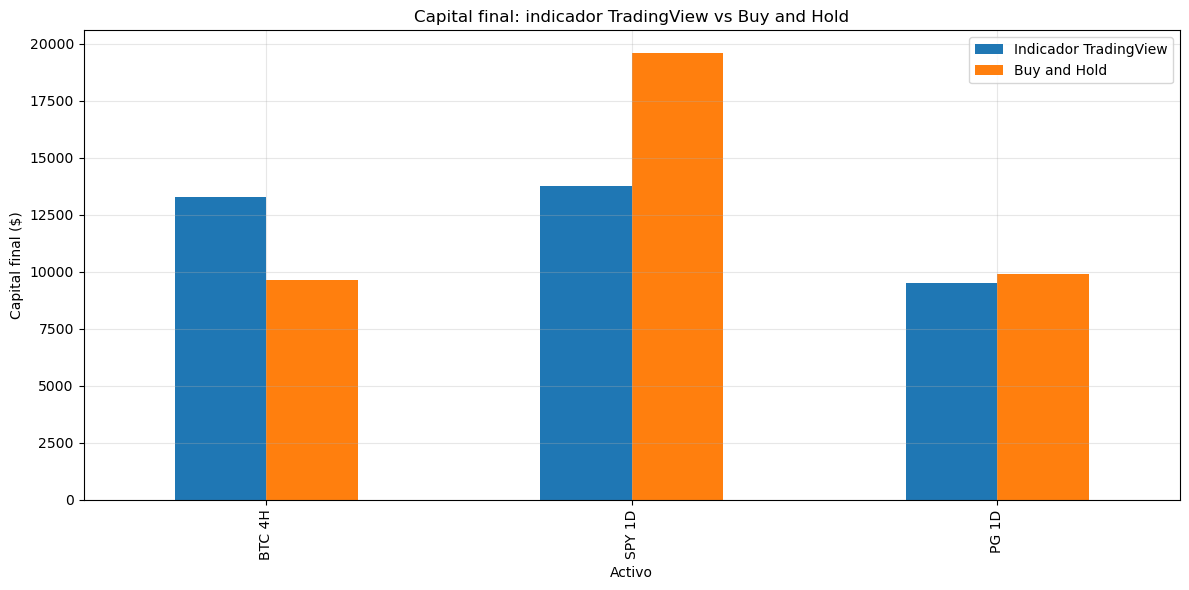

In [39]:
# ============================================================
# GRÁFICO DE CAPITAL FINAL: INDICADOR VS BUY AND HOLD
# ============================================================

plot_df = tradingview_vs_buy_hold[
    [
        "case_name",
        "final_capital_indicator",
        "final_capital_buy_hold"
    ]
].copy()

plot_df = plot_df.set_index("case_name")

ax = plot_df.plot(kind="bar", figsize=(12, 6))

ax.set_title("Capital final: indicador TradingView vs Buy and Hold")
ax.set_xlabel("Activo")
ax.set_ylabel("Capital final ($)")
ax.grid(True, alpha=0.3)
ax.legend(["Indicador TradingView", "Buy and Hold"])

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "tradingview_vs_buy_hold_final_capital.png",
    dpi=300
)
plt.show()

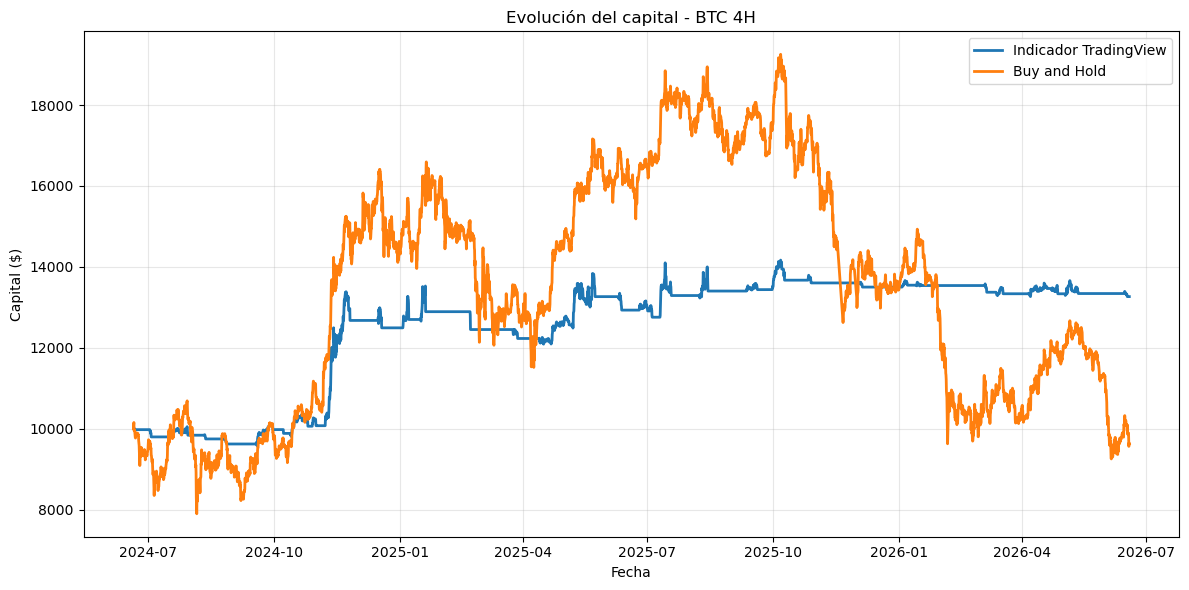

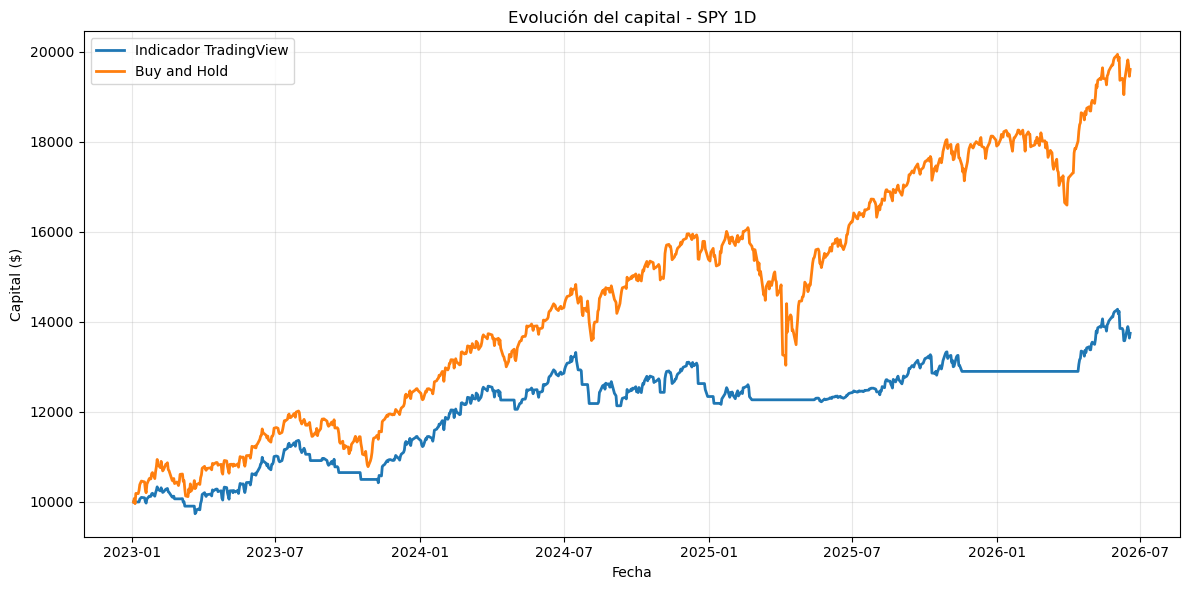

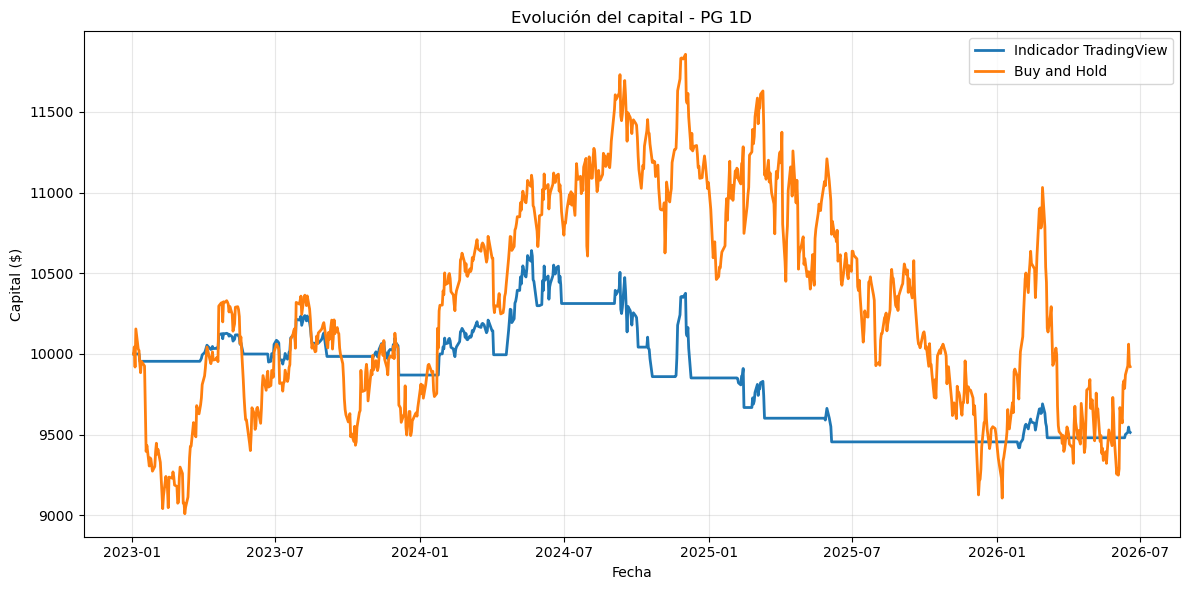

In [40]:
# ============================================================
# GRÁFICOS DE LÍNEAS: EVOLUCIÓN DEL CAPITAL
# ============================================================

cases_for_presentation = ["BTC 4H", "SPY 1D", "PG 1D"]

for case_name in cases_for_presentation:
    # Curva del indicador
    indicator_equity = tradingview_equity_curves[case_name]["equity"].copy()

    # Curva Buy and Hold sobre el mismo periodo
    ohlc_case = tradingview_ohlc_data[case_name]
    buy_hold_equity = (
        TRADINGVIEW_INITIAL_CAPITAL *
        (ohlc_case["close"] / ohlc_case["close"].iloc[0])
    )

    # Alinear fechas
    comparison_curves = pd.concat(
        [
            indicator_equity.rename("Indicador TradingView"),
            buy_hold_equity.rename("Buy and Hold")
        ],
        axis=1
    ).dropna()

    plt.figure(figsize=(12, 6))

    plt.plot(
        comparison_curves.index,
        comparison_curves["Indicador TradingView"],
        label="Indicador TradingView",
        linewidth=2
    )

    plt.plot(
        comparison_curves.index,
        comparison_curves["Buy and Hold"],
        label="Buy and Hold",
        linewidth=2
    )

    plt.title(f"Evolución del capital - {case_name}")
    plt.xlabel("Fecha")
    plt.ylabel("Capital ($)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = f"equity_curve_{case_name.replace(' ', '_').replace('-', '_')}.png"
    plt.savefig(FIGURES_DIR / filename, dpi=300)
    plt.show()

## Conclusión del experimento práctico

El backtest práctico del indicador muestra que la utilidad de una estrategia activa depende mucho del activo analizado y del régimen de mercado. La estrategia no pretende predecir el futuro, sino ajustar la exposición de la cartera según la fuerza de la señal: 100% en entradas fuertes, 50% en entradas moderadas, 25% en entradas contra régimen y 0% tras una señal de salida.
En **BTC 4H**, el indicador obtiene un capital final de **13.264,66 dólares**, equivalente a una rentabilidad del **32,65 %**, con un drawdown máximo del **−10,63 %**.

En **SPY 1D**, el indicador también obtiene rentabilidad positiva, con un capital final de 13.747,47 dólares y una rentabilidad del 37,47%. Sin embargo, este caso debe compararse con mucho cuidado frente a Buy and Hold. En un índice amplio como el S&P 500, que suele presentar una tendencia alcista estructural durante largos periodos, estar siempre invertido puede ser difícil de superar. La estrategia activa puede reducir riesgo en algunos tramos, pero también puede quedarse fuera durante rebotes o subidas sostenidas.

En **PG 1D**, el indicador no funciona bien. La estrategia termina con 9.513,57 dólares, lo que supone una rentabilidad del -4,86%. Este resultado es coherente con el comportamiento de un activo más defensivo y menos tendencial. En este tipo de valores, las señales basadas en EMA, RSI, ADX y ATR pueden aparecer tarde, cerrar posiciones demasiado pronto o no capturar movimientos suficientemente amplios. Además, en el análisis principal del notebook ya se observó que la mejora en PG procedía principalmente del modelo ARIMA, no de una estrategia técnica basada en medias móviles.

En conjunto, el experimento confirma que no existe una estrategia universal. El indicador puede ser útil en activos con volatilidad, tendencia y movimientos amplios, como BTC, pero puede perder eficacia en activos laterales o defensivos. En índices amplios como SPY, Buy and Hold sigue siendo un rival muy difícil de batir, porque permanecer invertido permite capturar toda la tendencia alcista acumulada. Por tanto, la decisión entre operar activamente o mantener una posición pasiva depende del activo, del régimen de mercado y del coste de quedarse fuera durante los tramos alcistas.
